# Student Submission

Fill in your IDs before submitting.

| | ID |
|---|----|
| Tal Hibner | 026548446 |
| Gilad Ticher | 318770039 |

# Deep RL in MiniGrid — Final Project (2026 B)

## Overview
Train **deep RL agents from scratch** — one from each of the value-based, policy-based, and actor-critic families —
on two image-based MiniGrid environments. The agent sees only the
**raw rendered RGB image** of the grid and must learn to act from pixels. No external RL libraries for the core
algorithms — use PyTorch / TensorFlow only for the neural networks.

**Read the accompanying PDF first.** This notebook defines the environment APIs and the editable points; the PDF
defines what to deliver. The **report** is the primary deliverable and must be fully
self-contained: every graph, table, number, and discussion point lives there.

## Learning objectives
- Implement one algorithm from each family — **value-based** (e.g. DQN), **policy-based** (e.g. REINFORCE), and
  **actor-critic** (e.g. A2C) — from scratch, and compare them.
- Design observation preprocessing and reward shaping as composable wrappers.
- Choose hyperparameters and an exploration strategy deliberately, and justify them.
- Evaluate with clear metrics and plots, and communicate results in a concise report.

## The two environments
| Environment | Description | Win condition |
|---|---|---|
| **`SimpleRoomEnv`** | Empty 10×10 room (sanity check) | Step onto the green goal |
| **`ComplexEnv`** | Two rooms: key → locked door → water → lava → goal | Ferry water to extinguish the lava ring, then reach the goal |

Both expose the standard MiniGrid `Discrete(7)` action space and a **raw full-grid RGB observation** (`uint8`,
`H·tile × W·tile × 3`).

## What you build — and where
- **Observation preprocessing** — a `gym.ObservationWrapper` (e.g. grayscale, resize, channel-first, frame-stack).
- **Reward shaping** — a `gym.Wrapper` / `gym.RewardWrapper` that adds shaping on top of the sparse reward.
- **The agents** — for each family, the network(s), update rule, training loop, and evaluation (e.g. replay buffer
  + target net for DQN; a policy network for REINFORCE; actor + critic for A2C).

Do all of this **outside** the environments. Provided **example wrappers** and an **environment explorer** come first;
write your own wrappers and agents below the **"Your Code Below"** divider near the end. **The environment classes are
fixed**; see the full edit policy in the *Environments* section below.

## Reproducibility & integrity
- Seed Python, NumPy, and your DL framework, and document every hyperparameter.
- Submit (1) this notebook with all training/inference outputs and (2) the report PDF — a reader should understand your
  full methodology and results from the report alone.
- Discuss ideas freely, but code and write-up must be your own; cite any external resources (blog posts, papers, code).

# Setup

## Installs

In [1]:
# Auto-install any missing dependencies. Idempotent: pip is only invoked for packages
# that aren't already importable, so re-running this cell is safe and cheap on both Colab
# and a local Python / venv kernel.
from __future__ import annotations

import importlib
import subprocess
import sys


def _pip_install(*packages: str) -> None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", *packages])


def _ensure(import_name: str, pip_name: str | None = None) -> None:
    try:
        importlib.import_module(import_name)
    except ImportError:
        _pip_install(pip_name or import_name)


_ensure("gymnasium")
_ensure("minigrid")
_ensure("numpy")
_ensure("matplotlib")
_ensure("cv2", "opencv-python")
_ensure("torch")
_ensure("imageio")
_ensure("imageio_ffmpeg", "imageio[ffmpeg]")   # mp4 backend for rollout videos
_ensure("ipywidgets")                          # inline env explorer (buttons)
# pyvirtualdisplay is only useful on a headless Linux host (e.g. Colab).
if "google.colab" in sys.modules or sys.platform.startswith("linux"):
    _ensure("pyvirtualdisplay")

## Imports

In [2]:
from __future__ import annotations

# Standard library
import base64
import os
import random
import sys
import time
from types import SimpleNamespace

# Numerics, plotting, video
import numpy as np
import matplotlib.pyplot as plt
import imageio

# Notebook display helpers
from IPython.display import HTML, display

# Gymnasium + MiniGrid
import gymnasium as gym
from gymnasium import spaces
from minigrid.core.grid import Grid
from minigrid.core.mission import MissionSpace
from minigrid.core.world_object import Ball, Door, Goal, Key, Lava, Wall
from minigrid.minigrid_env import MiniGridEnv as BaseMiniGridEnv

# Image preprocessing + deep learning
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F

# On headless Linux (e.g. Colab) MiniGrid's renderer needs a virtual display.
if "google.colab" in sys.modules or sys.platform.startswith("linux"):
    try:
        import pyvirtualdisplay
        pyvirtualdisplay.Display(visible=0, size=(1400, 900)).start()
    except Exception as exc:  # pragma: no cover
        print(f"[display] virtual display not started: {exc}")

%matplotlib inline
plt.rcParams["figure.figsize"] = (6.0, 5.0)

## Display utils
Save a rollout to an `.mp4` and embed it inline. Auto-detects Colab vs local Jupyter — no configuration needed.

In [3]:
def video_path(name: str, folder_name: str = "videos") -> str:
    """Return a writable absolute path for a video file under ``folder_name/``."""
    folder = os.path.join(os.getcwd(), folder_name)
    os.makedirs(folder, exist_ok=True)
    return os.path.join(folder, name)


def embed_mp4(filename: str):
    """Embed an mp4 file inline. Works in Colab and local Jupyter alike."""
    with open(filename, "rb") as f:
        b64 = base64.b64encode(f.read()).decode()
    tag = (
        '<video width="640" height="480" controls>'
        f'<source src="data:video/mp4;base64,{b64}" type="video/mp4">'
        "Your browser does not support the video tag."
        "</video>"
    )
    return HTML(tag)


def random_rollout_video(env, filename, max_steps=100, fps=10, seed=None):
    """Run one random-action episode and save it as mp4. Returns (steps, total_reward)."""
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)
    env.reset(seed=seed)
    total_reward, steps = 0.0, 0
    with imageio.get_writer(filename, fps=fps) as video:
        video.append_data(env.render())
        for steps in range(1, max_steps + 1):
            action = random.randint(0, env.action_space.n - 1)
            _, reward, terminated, truncated, _ = env.step(action)
            total_reward += float(reward)
            video.append_data(env.render())
            if terminated or truncated:
                break
    return steps, total_reward

# Environments — definition & construction

Two MiniGrid environments are defined below. **Both are fixed** — only `max_steps` may be overridden at
construction. Everything else (preprocessing, reward shaping, action restriction) goes in **wrappers**.

**Action IDs** (standard MiniGrid `Discrete(7)`):

| ID | Name | Effect |
|---|---|---|
| 0 | `left` | turn 90° left (no move) |
| 1 | `right` | turn 90° right (no move) |
| 2 | `forward` | move one cell forward |
| 3 | `pickup` | pick up the object directly in front |
| 4 | `drop` | drop the carried object into the cell in front |
| 5 | `toggle` | activate the object in front (open a door with the matching key; **extinguish a lava tile while carrying water**) |
| 6 | `done` | no-op here |

**Coordinates.** Cells are `(x, y)` with `x` growing **rightward** and `y` **downward**. Facing `agent_dir`:
`0`=right, `1`=down, `2`=left, `3`=up.

## Environment 1 — SimpleRoomEnv (sanity)

**Task.** Navigate from a random start to the green goal in an empty room.

| Property | Value |
|---|---|
| Grid | 10×10 (8×8 walkable) |
| Agent start | random interior cell, random facing |
| Goal | a random corner |
| Actions | `Discrete(7)` (only turn/forward are needed) |
| Reward | sparse: `+1` on the goal, `0` otherwise |
| Observation | raw full-grid RGB `uint8` |

In [4]:
# =============================================================================
# ENVIRONMENT 1: SimpleRoomEnv (empty room, sanity check)   --- FIXED, DO NOT EDIT
# =============================================================================
class SimpleRoomEnv(BaseMiniGridEnv):
    """Empty room: walk onto the green goal. Pass/fail sanity-check env.

    Same observation contract as ``ComplexEnv`` (raw full-grid RGB, uint8 HWC) and
    the standard MiniGrid ``Discrete(7)`` action space. Sparse reward ``+1`` on the
    goal. FIXED — wrap it to add preprocessing; you may only override ``max_steps``.
    """

    def __init__(self, width=10, height=10, max_steps=100, tile_size=32,
                 render_mode="rgb_array", **kwargs):
        assert width >= 4 and height >= 4
        mission_space = MissionSpace(mission_func=self._gen_mission)
        super().__init__(
            mission_space=mission_space, width=width, height=height,
            see_through_walls=True, max_steps=max_steps, render_mode=render_mode,
            highlight=False, **kwargs,
        )
        # --- spaces: Discrete(7) actions, raw full-grid RGB observation ---
        self.action_space = spaces.Discrete(7)
        self._obs_tile_size = int(tile_size)
        self.observation_space = spaces.Box(
            low=0, high=255,
            shape=(height * self._obs_tile_size, width * self._obs_tile_size, 3),
            dtype=np.uint8,
        )
        # --- per-episode layout: set by _gen_grid() ---
        self.goal_pos = None

    @staticmethod
    def _gen_mission():
        return "reach the green goal"

    def _gen_grid(self, width, height):
        self.grid = Grid(width, height)
        self.grid.wall_rect(0, 0, width, height)

        # goal in a random corner
        goal_x = int(self.np_random.choice([1, width - 2]))
        goal_y = int(self.np_random.choice([1, height - 2]))
        self.goal_pos = (goal_x, goal_y)
        self.put_obj(Goal(), goal_x, goal_y)

        # agent starts on any non-goal cell, facing a random direction
        while True:
            ax = int(self.np_random.integers(1, width - 1))
            ay = int(self.np_random.integers(1, height - 1))
            if (ax, ay) != self.goal_pos:
                break
        self.agent_pos = (ax, ay)
        self.agent_dir = int(self.np_random.integers(0, 4))
        self.mission = self._gen_mission()

    def gen_obs(self):
        return self.get_frame(highlight=False, tile_size=self._obs_tile_size)

    def is_on_goal(self) -> bool:
        """True iff the agent is standing on the goal cell right now (a win)."""
        return tuple(self.agent_pos) == tuple(self.goal_pos)

    def step(self, action):
        obs, _, _, truncated, info = super().step(action)
        terminated = self.is_on_goal()
        reward = 1.0 if terminated else 0.0
        return obs, reward, terminated, truncated, info

## Environment 2 — ComplexEnv (the task)

**Task — five stages: key → door → water → lava → goal.**
1. Pick up the **key** in the left room.
2. **Toggle** the locked partition **door** open (drop the key first if needed — only one object can be carried).
3. Pick up a **water ball** in the right room.
4. Face a **lava** tile and **toggle** to extinguish it; the tile clears and the ball is consumed. One ball per
   tile, so water must be **ferried repeatedly**.
5. Step onto the **goal** in the lava-ringed corner. Stepping on un-extinguished lava is **lethal**.

Objects may spawn in your path — the agent must learn to move them out of the way.

| Property | Value |
|---|---|
| Grid | 10×10, two rooms split by a partition wall (`partition_col=3`) |
| Agent start | `(1, 1)`, random facing |
| Key / Door | one key at a random left-room cell; one locked door at a random partition row |
| Water balls | a contiguous cluster in the top or bottom left of the right room (`water_corner`) |
| Lava | rings the goal corner; lethal until extinguished |
| Goal | top or bottom right-room corner (`goal_corner`) |
| Actions | `Discrete(7)` (turn / forward / pickup / drop / toggle all matter) |
| Reward | sparse: `+1` on the goal, `0` otherwise; lava death ends the episode with `0` |
| Observation | raw full-grid RGB `uint8` |

**Helper getters.** The observation is raw RGB, so there is no tabular state to read. `ComplexEnv` exposes
`is_*` / `prev_*` getters (current vs. start-of-step) plus position getters — see the class docstring (next
code cell) for the full list. They exist for wrappers (event detection) and analysis; reward may **not** use
geometry or distance.

**`info` dict** (from `step` / `reset`): `is_success`, `died_on_lava`, `extinguished_lava_count`, `n_lava`,
`extinguished_this_step`.

In [5]:
# =============================================================================
# ENVIRONMENT 2: ComplexEnv (key -> door -> water -> lava -> goal)  --- FIXED, DO NOT EDIT
# =============================================================================
class ComplexEnv(BaseMiniGridEnv):
    """Key -> door -> water -> lava -> goal (image-based, sparse reward).

    The left room holds a single locked-door key; the right room holds the goal in
    a top or bottom right corner ringed by lethal ``Lava`` (the ring mirrors with
    the corner), plus several ``Ball`` "water" objects.
    To win: pick up the key, toggle the locked door open, drop the key (only one
    object can be carried), pick up a water ball, ``toggle`` it while facing a lava
    tile (extinguishes that tile and consumes the ball) -- ferrying water until the
    path is clear -- then step onto the goal. Stepping on un-extinguished lava is lethal.

    Observation: raw full-grid RGB ``(H*tile, W*tile, 3)`` uint8. Reward: sparse
    ``+1`` on the goal, ``0`` otherwise. FIXED -- wrap it to add preprocessing / reward
    shaping; you may only override ``max_steps``.


    Helper getters -- for event-based reward shaping and for evaluation / EDA. (The
    observation is the raw RGB image, so there is no tabular "state" to read here; and
    reward may NOT depend on geometry / distance, so the position getters are for
    analysis, not for shaping.)
      curr (now)            : is_carrying_key / is_carrying_water / is_door_open /
                              is_door_locked / is_on_lava / is_on_goal / is_in_right_room /
                              extinguished_lava_count
      prev (start of step)  : prev_carrying_key / prev_carrying_water / prev_door_open /
                              prev_door_locked / prev_in_right_room / prev_extinguished_lava_count
      positions (eval & EDA): key_position / water_positions / lava_positions
    Detect an event as *curr and not prev*, e.g.
    just picked up water == ``is_carrying_water() and not prev_carrying_water()``.
    Latch a milestone ("ever opened the door") yourself in your wrapper if you want one.
    """

    def __init__(self, max_steps=400, width=10, height=10, tile_size=32,
                 render_mode="rgb_array", partition_col=3,
                 agent_start_pos=(1, 1), goal_corner="random",
                 n_water=3, water_corner="random",
                 key_door_color="purple", water_color="blue", **kwargs):
        assert width >= 8 and height >= 5
        assert 2 <= partition_col < width - 2   # leave >=1 right-room column for the goal
        assert goal_corner in ("top", "bottom", "random")
        assert water_corner in ("top", "bottom", "random")
        mission_space = MissionSpace(mission_func=self._gen_mission)
        super().__init__(
            mission_space=mission_space, width=width, height=height,
            see_through_walls=True, max_steps=max_steps, render_mode=render_mode,
            highlight=False, **kwargs,
        )
        # --- spaces: Discrete(7) actions, raw full-grid RGB observation ----------------
        self.action_space = spaces.Discrete(7)
        self._obs_tile_size = int(tile_size)
        self.observation_space = spaces.Box(
            low=0, high=255,
            shape=(height * self._obs_tile_size, width * self._obs_tile_size, 3),
            dtype=np.uint8,
        )

        # --- task configuration: fixed for the env's lifetime (from constructor args) --
        self.partition_col = partition_col
        self.key_color = key_door_color
        self.door_color = key_door_color
        self.water_color = water_color
        self.n_water = int(n_water)
        self.goal_corner = goal_corner           # "top" / "bottom" / "random" (resolved per episode)
        self.water_corner = water_corner         # "top" / "bottom" / "random" (resolved per episode)
        # agent start: None -> randomized per episode; otherwise reused each episode.
        self.fixed_agent_start_pos = (None if agent_start_pos is None
                                      else tuple(int(v) for v in agent_start_pos))

        # --- per-episode layout: (re)filled by _gen_grid() on every reset ---------------
        self.door_pos = None
        self.goal_pos = None
        self.lava_ring = ()                 # ring around the goal corner (mirrors it)
        self._door = None

        # --- episode progress: count of lava tiles extinguished so far this episode -----
        self._extinguished_lava_count = 0

        # --- previous-step snapshot: each value as of the START of the current step ------
        self._prev_carrying_key = False
        self._prev_carrying_water = False
        self._prev_door_open = False
        self._prev_door_locked = False
        self._prev_in_right_room = False
        self._prev_extinguished_lava_count = 0

    @staticmethod
    def _gen_mission():
        return "get the key, open the door, extinguish the lava with water, then reach the goal"

    def _resolve_corner(self, mode):
        """Resolve a 'top'/'bottom'/'random' corner mode to a concrete 'top'/'bottom'
        for this episode ('random' is re-rolled every episode via the env RNG)."""
        if mode == "random":
            return "top" if int(self.np_random.integers(0, 2)) == 0 else "bottom"
        return mode

    def _gen_grid(self, width, height):
        self.grid = Grid(width, height)
        self.grid.wall_rect(0, 0, width, height)

        # partition wall splitting left (key) from right (goal + lava + water)
        for y in range(height):
            self.grid.set(self.partition_col, y, Wall())

        # locked door at a random partition row
        door_y = int(self.np_random.integers(1, height - 1))
        self.door_pos = (self.partition_col, door_y)
        self._door = Door(self.door_color, is_locked=True)
        self.grid.set(self.partition_col, door_y, self._door)

        # agent start: fixed if provided, else a random left-room cell, facing random
        if self.fixed_agent_start_pos is not None:
            self.agent_pos = self.fixed_agent_start_pos
        else:
            ax = int(self.np_random.integers(1, self.partition_col))
            ay = int(self.np_random.integers(1, height - 1))
            self.agent_pos = (ax, ay)
        self.agent_dir = int(self.np_random.integers(0, 4))

        # the single key on a left-room cell (never UNDER the agent). It MAY land on the
        # door-approach cell -- no clearance is reserved, so it can block the way.
        blocked = {tuple(self.agent_pos)}
        left_cells = [(x, y) for x in range(1, self.partition_col)
                      for y in range(1, height - 1) if (x, y) not in blocked]
        kx, ky = left_cells[int(self.np_random.integers(len(left_cells)))]
        self.grid.set(kx, ky, Key(self.key_color))

        # goal in a right-room corner (top or bottom); the lava ring mirrors with it so
        # it always cups the goal corner. The goal stays in the far-right column (x=width-2).
        goal_corner = self._resolve_corner(self.goal_corner)
        gx = width - 2
        if goal_corner == "bottom":
            self.goal_pos = (gx, height - 2)
            self.lava_ring = ((gx - 1, height - 2), (gx, height - 3), (gx - 1, height - 3))
        else:  # top: vertical mirror of the bottom ring
            self.goal_pos = (gx, 1)
            self.lava_ring = ((gx - 1, 1), (gx, 2), (gx - 1, 2))
        self.put_obj(Goal(), self.goal_pos[0], self.goal_pos[1])

        # lethal lava ringing the goal corner
        for lx, ly in self.lava_ring:
            self.grid.set(lx, ly, Lava())

        # water balls: a contiguous cluster on the top or bottom row (water_corner), starting
        # at the left edge of the right room. Cells overlapping the goal/lava are skipped, so a
        # large n_water relative to the room width may place fewer than n_water balls.
        water_corner = self._resolve_corner(self.water_corner)
        wy = 1 if water_corner == "top" else height - 2
        reserved = {tuple(self.goal_pos)} | set(self.lava_ring)
        placements = []
        for i in range(self.n_water):
            wx = self.partition_col + 1 + i
            if wx > width - 2:
                break
            if (wx, wy) not in reserved:
                placements.append((wx, wy))
        for wx, wy in placements:
            self.grid.set(wx, wy, Ball(self.water_color))

        # reset the per-episode extinguished-lava count (the prev snapshot is taken in
        # reset, once the base class has finished setting up self.carrying etc.)
        self._extinguished_lava_count = 0
        self.mission = self._gen_mission()

    def reset(self, *, seed=None, options=None):
        obs, info = super().reset(seed=seed, options=options)   # calls _gen_grid()
        self._snapshot_prev()                                   # prev == the fresh reset state
        info = dict(info)
        info.update(self._info_snapshot(terminated=False, extinguished_now=0))
        return obs, info

    def gen_obs(self):
        return self.get_frame(highlight=False, tile_size=self._obs_tile_size)

    # ============================ curr: instantaneous state (true only RIGHT NOW) =======
    def is_carrying_key(self) -> bool:
        """True iff a key is in hand right now."""
        return isinstance(self.carrying, Key)

    def is_carrying_water(self) -> bool:
        """True iff a water ball is in hand right now."""
        return isinstance(self.carrying, Ball)

    def is_door_open(self) -> bool:
        """True iff the door is open right now."""
        return bool(self._door is not None and self._door.is_open)

    def is_door_locked(self) -> bool:
        """True iff the door is locked right now (opening it unlocks it for good)."""
        return bool(self._door is not None and self._door.is_locked)

    def is_on_lava(self) -> bool:
        """True iff the agent is standing on a lava tile right now (a lethal lava death)."""
        return isinstance(self.grid.get(int(self.agent_pos[0]), int(self.agent_pos[1])), Lava)

    def is_on_goal(self) -> bool:
        """True iff the agent is standing on the goal cell right now (a win)."""
        return tuple(int(v) for v in self.agent_pos) == tuple(int(v) for v in self.goal_pos)

    def is_in_right_room(self) -> bool:
        """True iff the agent is past the partition wall (right room)."""
        return int(self.agent_pos[0]) > self.partition_col

    def extinguished_lava_count(self) -> int:
        """How many lava tiles have been extinguished so far this episode (only grows)."""
        return self._extinguished_lava_count

    # ============================ prev: same state, as of the START of this step ========
    def prev_carrying_key(self) -> bool: return self._prev_carrying_key
    def prev_carrying_water(self) -> bool: return self._prev_carrying_water
    def prev_door_open(self) -> bool: return self._prev_door_open
    def prev_door_locked(self) -> bool: return self._prev_door_locked
    def prev_in_right_room(self) -> bool: return self._prev_in_right_room
    def prev_extinguished_lava_count(self) -> int: return self._prev_extinguished_lava_count

    # ============================ positions / layout: for evaluation / EDA ==============
    def key_position(self) -> tuple[int, int] | None:
        """The single key's (x, y) while uncarried, else None (its color is ``key_color``)."""
        for x in range(self.width):
            for y in range(self.height):
                if isinstance(self.grid.get(x, y), Key):
                    return (x, y)
        return None

    def water_positions(self) -> list:
        """Remaining (uncarried) water balls on the grid."""
        return [(x, y) for x in range(self.width) for y in range(self.height)
                if isinstance(self.grid.get(x, y), Ball)]

    def lava_positions(self) -> list:
        """Lava tiles still present (not yet extinguished)."""
        return [(x, y) for x in range(self.width) for y in range(self.height)
                if isinstance(self.grid.get(x, y), Lava)]

    # ============================ internal bookkeeping ==================================
    def _snapshot_prev(self):
        """Capture the instantaneous state so the prev_* getters describe the value as
        of the START of the next step (i.e. the last step's value)."""
        self._prev_carrying_key = self.is_carrying_key()
        self._prev_carrying_water = self.is_carrying_water()
        self._prev_door_open = self.is_door_open()
        self._prev_door_locked = self.is_door_locked()
        self._prev_in_right_room = self.is_in_right_room()
        self._prev_extinguished_lava_count = self._extinguished_lava_count

    def _faced_lava_to_extinguish(self, action):
        """Return the (x, y) of the lava tile this action would extinguish -- i.e.
        ``toggle`` while carrying water and facing lava -- or None. (Base MiniGrid has
        no toggle behaviour for lava, so we resolve it ourselves.)"""
        if int(action) != int(self.actions.toggle) or not isinstance(self.carrying, Ball):
            return None
        fx, fy = (int(v) for v in self.front_pos)
        return (fx, fy) if isinstance(self.grid.get(fx, fy), Lava) else None

    def _resolve_goal(self, terminated):
        """Win (+1, terminate) on the goal cell; otherwise keep the base ``terminated``
        so a step onto un-extinguished lava stays lethal (death ends with no reward)."""
        if self.is_on_goal():
            return 1.0, True
        return 0.0, terminated

    def _info_snapshot(self, *, terminated, extinguished_now):
        """Ground-truth signals the env owns, surfaced through ``info`` for logging /
        evaluation."""
        return {
            "extinguished_lava_count": int(self._extinguished_lava_count),
            "n_lava": len(self.lava_ring),
            "extinguished_this_step": int(extinguished_now),
            "is_success": bool(self.is_on_goal()),
            "died_on_lava": bool(terminated and not self.is_on_goal()),
        }

    # ============================ step / reward =========================================
    def step(self, action):
        self._snapshot_prev()   # 'prev' = state as of the start of this step

        extinguish_target = self._faced_lava_to_extinguish(action)
        obs, _, terminated, truncated, info = super().step(action)

        extinguished_now = 0
        if extinguish_target is not None:
            ex, ey = extinguish_target
            self.grid.set(ex, ey, None)     # lava -> empty floor
            self.carrying = None            # the water ball is consumed
            self._extinguished_lava_count += 1
            extinguished_now = 1
            obs = self.gen_obs()            # refresh the image after the change

        reward, terminated = self._resolve_goal(terminated)

        info = dict(info)
        info.update(self._info_snapshot(terminated=terminated, extinguished_now=extinguished_now))
        return obs, reward, terminated, truncated, info

# Environment exploration

Get a feel for both envs before building anything — inspect the API and getters, the initial state, and a
random-action rollout. Nothing here is graded.

=== SimpleRoomEnv ===
obs shape / dtype : (320, 320, 3)  uint8
action space      : Discrete(7)
agent pos / dir   : (6, 4)  dir=1
goal_pos          : (1, 8)
info              : {}

=== ComplexEnv ===
obs shape / dtype : (320, 320, 3)  uint8
action space      : Discrete(7)
agent pos / dir   : (1, 1)  dir=3
door color / pos  : purple  (3, 1)
goal_pos          : (8, 1)
key   position    : (2, 3)  color=purple
water positions   : [(4, 1), (5, 1), (6, 1)]
lava  positions   : [(7, 1), (7, 2), (8, 2)]
-- curr state at reset --
carrying_key=False  carrying_water=False  in_right_room=False
door_open=False  door_locked=True  on_lava=False  on_goal=False
extinguished lava tiles : 0
info keys          : ['died_on_lava', 'extinguished_lava_count', 'extinguished_this_step', 'is_success', 'n_lava']


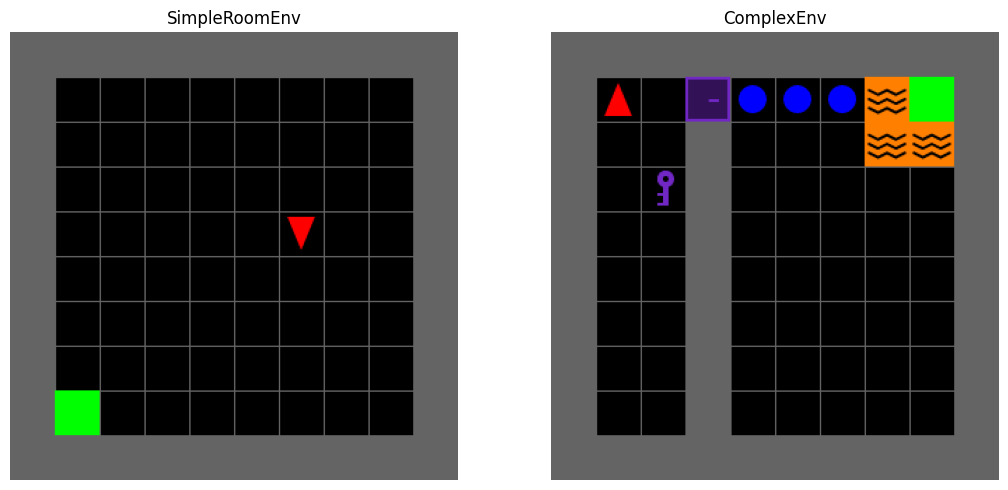

In [6]:
# Environment info + initial-state render for both envs, side by side.
simple_env = SimpleRoomEnv(max_steps=100)
s_obs, s_info = simple_env.reset(seed=42)

env = ComplexEnv(max_steps=400)
c_obs, c_info = env.reset(seed=42)

print("=== SimpleRoomEnv ===")
print(f"obs shape / dtype : {s_obs.shape}  {s_obs.dtype}")
print(f"action space      : {simple_env.action_space}")
print(f"agent pos / dir   : {simple_env.agent_pos}  dir={simple_env.agent_dir}")
print(f"goal_pos          : {simple_env.goal_pos}")
print(f"info              : {s_info}")

print("\n=== ComplexEnv ===")
print(f"obs shape / dtype : {c_obs.shape}  {c_obs.dtype}")
print(f"action space      : {env.action_space}")
print(f"agent pos / dir   : {env.agent_pos}  dir={env.agent_dir}")
print(f"door color / pos  : {env.door_color}  {env.door_pos}")
print(f"goal_pos          : {env.goal_pos}")
print(f"key   position    : {env.key_position()}  color={env.key_color}")
print(f"water positions   : {env.water_positions()}")
print(f"lava  positions   : {env.lava_positions()}")
print("-- curr state at reset --")
print(f"carrying_key={env.is_carrying_key()}  carrying_water={env.is_carrying_water()}  "
      f"in_right_room={env.is_in_right_room()}")
print(f"door_open={env.is_door_open()}  door_locked={env.is_door_locked()}  "
      f"on_lava={env.is_on_lava()}  on_goal={env.is_on_goal()}")
print(f"extinguished lava tiles : {env.extinguished_lava_count()}")
print(f"info keys          : {sorted(c_info)}")

# Initial-state render, both envs side by side.
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, e, title in ((axes[0], simple_env, "SimpleRoomEnv"), (axes[1], env, "ComplexEnv")):
    ax.imshow(e.render())
    ax.set_title(title)
    ax.axis("off")
fig.tight_layout()
plt.show()

In [7]:
# Random-action rollouts for both envs, shown side by side.
# (Random actions rarely make progress on either env -- that's expected.)
simple_video = video_path("SimpleRoomEnv_random.mp4")
s_steps, s_total = random_rollout_video(simple_env, simple_video, max_steps=100, seed=1)
print(f"SimpleRoomEnv random rollout: steps={s_steps}, total_reward={s_total:.2f}")

complex_video = video_path("ComplexEnv_random.mp4")
c_steps, c_total = random_rollout_video(env, complex_video, max_steps=100, seed=1)
print(f"ComplexEnv  random rollout: steps={c_steps}, total_reward={c_total:.2f}")


def _b64(path):
    with open(path, "rb") as f:
        return base64.b64encode(f.read()).decode()


display(HTML(f"""
<div style="display:flex; gap:16px; flex-wrap:wrap; align-items:flex-start;">
  <figure style="margin:0; text-align:center;">
    <figcaption><b>SimpleRoomEnv</b></figcaption>
    <video width="420" height="300" controls>
      <source src="data:video/mp4;base64,{_b64(simple_video)}" type="video/mp4">
    </video>
  </figure>
  <figure style="margin:0; text-align:center;">
    <figcaption><b>ComplexEnv</b></figcaption>
    <video width="420" height="300" controls>
      <source src="data:video/mp4;base64,{_b64(complex_video)}" type="video/mp4">
    </video>
  </figure>
</div>
"""))

SimpleRoomEnv random rollout: steps=100, total_reward=0.00
ComplexEnv  random rollout: steps=100, total_reward=0.00


# Preprocessing & reward shaping — via wrappers

Everything outside the fixed envs is done with Gymnasium wrappers:

- **Observation preprocessing** → `gym.ObservationWrapper` (override `observation(obs)`, update `observation_space`).
- **Reward shaping** → `gym.Wrapper` / `gym.RewardWrapper` (modify the reward in `step`, reading the env getters).
- **Action subset** → `gym.ActionWrapper` (restrict the 7 actions).

Wrappers compose, e.g. `GrayscaleWrapper(ShapingWrapper(ComplexEnv()))`; reach the base env via `env.unwrapped`.
The next cell provides three **example wrappers** as starting points.

## Example wrappers (starter code)

Three minimal examples to build on:
1. `GrayscaleWrapper` — RGB → single-channel grayscale.
2. `EventShapingWrapper` — scale the sparse goal reward and add a one-off event bonus via the env getters.
3. `ActionSubsetWrapper` — expose only a subset of the actions.

In [8]:
class GrayscaleWrapper(gym.ObservationWrapper):
    """Example: convert the raw RGB observation (H, W, 3) to grayscale (H, W, 1)."""

    def __init__(self, env):
        super().__init__(env)
        h, w, _ = env.observation_space.shape
        self.observation_space = spaces.Box(low=0, high=255, shape=(h, w, 1), dtype=np.uint8)

    def observation(self, obs):
        gray = cv2.cvtColor(obs, cv2.COLOR_RGB2GRAY)
        return gray[:, :, None]   # (H, W) -> (H, W, 1)

In [9]:
class EventShapingWrapper(gym.Wrapper):
    """Example: scale the sparse env reward and add tiny event-based shaping."""

    def __init__(self, env, base_reward_scale: float = 10.0,
                 door_bonus: float = 1.0, step_penalty: float = 0.01):
        super().__init__(env)
        self.base_reward_scale = float(base_reward_scale)
        self.door_bonus = float(door_bonus)
        self.step_penalty = float(step_penalty)

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        core_env = self.env.unwrapped
        reward = self.base_reward_scale * float(reward) - self.step_penalty
        if core_env.is_door_open() and not core_env.prev_door_open():   # door just opened
            reward += self.door_bonus
        return obs, reward, terminated, truncated, info

In [10]:
class ActionSubsetWrapper(gym.ActionWrapper):
    """Example: expose only a chosen subset of the 7 MiniGrid actions as a smaller,
    contiguous Discrete space. The agent picks an index ``0..k-1`` and the wrapper
    maps it back to the real MiniGrid action id. Dropping actions the task never needs
    (e.g. ``done``) shrinks the space the agent has to explore.
    """

    def __init__(self, env, action_ids=(0, 1, 2, 3, 4, 5)):
        super().__init__(env)
        self.action_ids = tuple(int(a) for a in action_ids)
        self.action_space = spaces.Discrete(len(self.action_ids))

    def action(self, act):
        return self.action_ids[int(act)]   # policy index -> real MiniGrid action id

wrapped obs shape / dtype : (320, 320, 1)  uint8
observation_space         : Box(0, 255, (320, 320, 1), uint8)
action_space              : Discrete(6)  (subset of the 7 MiniGrid actions)


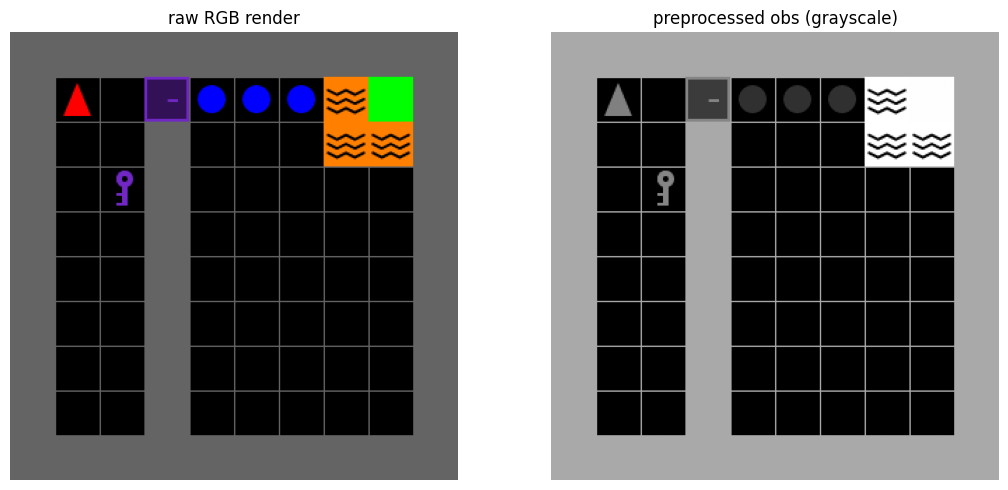

In [11]:
# Compose the example wrappers and inspect the result. Order matters.
demo = ComplexEnv(max_steps=400)
demo = EventShapingWrapper(demo, base_reward_scale=10.0, door_bonus=1.0, step_penalty=0.01)
demo = ActionSubsetWrapper(demo, action_ids=(0, 1, 2, 3, 4, 5))
demo = GrayscaleWrapper(demo)

obs, info = demo.reset(seed=42)
print(f"wrapped obs shape / dtype : {obs.shape}  {obs.dtype}")
print(f"observation_space         : {demo.observation_space}")
print(f"action_space              : {demo.action_space}  (subset of the 7 MiniGrid actions)")

raw = demo.unwrapped.render()                       # full-color render of the same state
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].imshow(raw); axes[0].set_title("raw RGB render"); axes[0].axis("off")
axes[1].imshow(obs.squeeze(), cmap="gray")
axes[1].set_title("preprocessed obs (grayscale)"); axes[1].axis("off")
plt.tight_layout(); plt.show()

## Environment explorer (drive an env by hand)

Step an env one action at a time with buttons, rendered inline, watching the reward, getters, and status
flags update. Point it at a **wrapped** env to see your shaped / scaled reward and preprocessed pipeline
(state read-outs come from `env.unwrapped`).

**Requires** `ipywidgets` and `env_explorer.py` in the working directory (in Colab, drag the file into
the **Files** panel). Safe to skip if a dependency is missing. Re-run after editing an env or a wrapper.

In [12]:
# Optional manual driver. Drive a *wrapped* env by hand to watch shaped reward + getters as you act.
# (Pass `ComplexEnv` instead for the bare env.) On Colab: drag env_explorer.py into Files first.
def make_explore_env():
    env = ComplexEnv(max_steps=400)
    env = EventShapingWrapper(env, base_reward_scale=10.0, door_bonus=1.0, step_penalty=0.01)
    env = ActionSubsetWrapper(env, action_ids=(0, 1, 2, 3, 4, 5))
    env = GrayscaleWrapper(env)
    return env

print("Optional env_explorer cell skipped for Run All.")
# try:
#     from env_explorer import explore_env
#     explore_env(make_explore_env, seed=None)        # or explore_env(ComplexEnv) for the raw env
# except Exception as exc:
#     print(f"[explorer] not started: {exc}")

Optional env_explorer cell skipped for Run All.


# Your Code Below

Everything below is yours — add as many cells as you need. Build your wrappers and agents here; see the PDF
for the deliverables. Good luck!

## Device

In [13]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


## Reproducibility & Utilities


In [14]:
import json
ARTIFACTS = os.path.join(os.getcwd(), "artifacts")
for sub in ("logs", "plots", "checkpoints"):
    os.makedirs(os.path.join(ARTIFACTS, sub), exist_ok=True)

def save_agent(agent, name):
    path = os.path.join(ARTIFACTS, "checkpoints", f"{name}.pt")
    state = {a: getattr(agent, a).state_dict()
             for a in ("q_net", "target_net", "policy", "value_net", "network")
             if hasattr(agent, a)}
    torch.save(state, path)
    return path

def save_figure(fig, name):
    path = os.path.join(ARTIFACTS, "plots", f"{name}.png")
    fig.savefig(path, dpi=120, bbox_inches="tight")
    return path

# ---------------------------------------------------------------------------
# Seeding — call once at the top of each training run
# ---------------------------------------------------------------------------
def set_seed(seed=42):
    """Seed Python, NumPy, and PyTorch for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

def episode_seed(seed, episode_idx, phase="train"):
    """Deterministic per-episode seed for env.reset()."""
    phase_offset = {"train": 0, "eval": 10_000_000, "video": 20_000_000}.get(phase, 0)
    return int(seed) + phase_offset + int(episode_idx)


# ---------------------------------------------------------------------------
# Training logger — stores per-episode metrics
# ---------------------------------------------------------------------------
class TrainingLogger:
    """Lightweight per-episode metric store for training runs."""

    def __init__(self):
        self.rewards = []
        self.sparse_rewards = []
        self.steps = []
        self.successes = []
        self.cumulative_steps = []
        self.total_steps = 0
        self.stages = []          # ComplexEnv: max stage reached per episode

    def log(self, reward, steps, success, info=None, sparse_reward=0.0):
        self.rewards.append(float(reward))
        self.sparse_rewards.append(float(sparse_reward))
        self.steps.append(int(steps))
        self.successes.append(float(success))
        self.total_steps += int(steps)
        self.cumulative_steps.append(self.total_steps)
        if info is not None and "stage_reached" in info:
            self.stages.append(info["stage_reached"])

    def get_success_rate(self, window=100):
        if not self.successes:
            return 0.0
        recent = self.successes[-window:]
        return sum(recent) / len(recent)

# ---------------------------------------------------------------------------

def save_logger(logger, name):
    path = os.path.join(ARTIFACTS, "logs", f"{name}.json")
    with open(path, "w") as f:
        json.dump({k: v for k, v in vars(logger).items()
                   if isinstance(v, (list, int, float))}, f)
    return path

def load_logger(name):
    path = os.path.join(ARTIFACTS, "logs", f"{name}.json")
    with open(path, "r") as f:
        data = json.load(f)

    logger = TrainingLogger()
    for k, v in data.items():
        setattr(logger, k, v)

    # Backwards compatibility if older saved logs do not include sparse_rewards
    if not hasattr(logger, "sparse_rewards"):
        logger.sparse_rewards = [0.0] * len(logger.rewards)

    return logger


# ---------------------------------------------------------------------------
# Plotting helpers
# ---------------------------------------------------------------------------
def _rolling(data, window):
    """Simple rolling average via convolution."""
    data = list(data)
    if len(data) == 0:
        return np.array([])
    window = max(1, min(window, len(data)))
    kernel = np.ones(window) / window
    return np.convolve(data, kernel, mode="valid")


def plot_training(logger, title="Training", window=50):
    """4-panel training curves for a single run."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(title, fontsize=16, fontweight="bold")

    # Reward
    ax = axes[0, 0]
    data = logger.rewards
    ax.plot(data, alpha=0.25, color="royalblue")
    r = _rolling(data, window)
    x0 = max(0, len(data) - len(r))
    ax.plot(range(x0, x0 + len(r)), r, color="royalblue", lw=2)
    ax.set(xlabel="Episode", ylabel="Reward", title="Reward per Episode")
    ax.grid(True, alpha=0.3)

    # Steps
    ax = axes[0, 1]
    data = logger.steps
    ax.plot(data, alpha=0.25, color="seagreen")
    r = _rolling(data, window)
    x0 = max(0, len(data) - len(r))
    ax.plot(range(x0, x0 + len(r)), r, color="seagreen", lw=2)
    ax.set(xlabel="Episode", ylabel="Steps", title="Steps per Episode")
    ax.grid(True, alpha=0.3)

    # Success rate
    ax = axes[1, 0]
    data = logger.successes
    r = _rolling(data, window)
    x0 = max(0, len(data) - len(r))
    ax.plot(range(x0, x0 + len(r)), r, color="crimson", lw=2)
    ax.set(xlabel="Episode", ylabel="Success Rate",
           title=f"Success Rate (rolling {window})")
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, alpha=0.3)

    # Cumulative env steps
    ax = axes[1, 1]
    ax.plot(logger.cumulative_steps, color="darkorchid", lw=2)
    ax.set(xlabel="Episode", ylabel="Cumulative Steps",
           title="Cumulative Environment Steps")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    return fig


def plot_comparison(loggers, names, title="Algorithm Comparison", window=50):
    """Overlay training curves for multiple algorithms."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(title, fontsize=16, fontweight="bold")
    colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

    for i, (lg, name) in enumerate(zip(loggers, names)):
        c = colors[i % len(colors)]
        for ax_idx, (data_attr, ylabel, ytitle) in enumerate([
            ("rewards", "Reward", "Reward per Episode"),
            ("steps", "Steps", "Steps per Episode"),
            ("successes", "Success Rate", f"Success Rate (rolling {window})"),
            ("cumulative_steps", "Cumulative Steps", "Cumulative Env Steps"),
        ]):
            ax = axes[ax_idx // 2, ax_idx % 2]
            data = getattr(lg, data_attr)
            if data_attr == "cumulative_steps":
                ax.plot(data, color=c, label=name, lw=2)
            else:
                r = _rolling(data, window)
                x0 = max(0, len(data) - len(r))
                ax.plot(range(x0, x0 + len(r)), r, color=c, label=name, lw=2)
            ax.set(xlabel="Episode", ylabel=ylabel, title=ytitle)
            if data_attr == "successes":
                ax.set_ylim(-0.05, 1.05)
            ax.legend()
            ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    return fig


def plot_stage_progress(logger, title="ComplexEnv Stage Progress", window=50):
    """Stage-reached scatter + distribution for ComplexEnv runs."""
    if not logger.stages:
        print("No stage data to plot.")
        return
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=16, fontweight="bold")

    ax = axes[0]
    data = logger.stages
    ax.scatter(range(len(data)), data, alpha=0.2, s=8, c="teal")
    r = _rolling(data, window)
    x0 = max(0, len(data) - len(r))
    ax.plot(range(x0, x0 + len(r)), r, color="crimson", lw=2)
    ax.set(xlabel="Episode", ylabel="Stage", title="Max Stage per Episode")
    ax.set_yticks(range(6))
    ax.set_yticklabels(["None", "Key", "Door", "Water", "Lava", "Goal"])
    ax.grid(True, alpha=0.3)

    ax = axes[1]
    labels = ["None", "Key", "Door", "Water", "Lava", "Goal"]
    counts = [logger.stages.count(i) for i in range(6)]
    bar_colors = ["#999", "#9b59b6", "#8B4513", "#3498db", "#e67e22", "#2ecc71"]
    ax.bar(labels, counts, color=bar_colors)
    ax.set(xlabel="Stage", ylabel="Episodes", title="Stage Distribution")
    ax.grid(True, alpha=0.3, axis="y")

    plt.tight_layout()
    plt.show()
    return fig

print("Utilities loaded.")


Utilities loaded.


## Wrappers: Preprocessing & Reward Shaping


In [ ]:
class SparseReturnTracker(gym.Wrapper):
    """Innermost shim: expose true sparse env reward via info['sparse_reward']."""
    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        info = dict(info)
        info["sparse_reward"] = float(reward)
        return obs, reward, terminated, truncated, info


class PreprocessWrapper(gym.ObservationWrapper):
    """Resize to (size x size), optional grayscale, HWC -> CHW, normalise to [0,1]."""

    def __init__(self, env, size=84, grayscale=False):
        super().__init__(env)
        self.size = size
        self.grayscale = grayscale
        c = 1 if grayscale else 3
        self.observation_space = spaces.Box(
            low=0.0, high=1.0, shape=(c, size, size), dtype=np.float32)

    def observation(self, obs):
        if self.grayscale:
            obs = cv2.cvtColor(obs, cv2.COLOR_RGB2GRAY)
        obs = cv2.resize(obs, (self.size, self.size), interpolation=cv2.INTER_AREA)
        if obs.ndim == 2:
            obs = obs[:, :, None]
        obs = np.transpose(obs, (2, 0, 1))
        return obs.astype(np.float32) / 255.0


class SimpleShapingWrapper(gym.Wrapper):
    """Scale the sparse goal reward and add a per-step penalty."""

    def __init__(self, env, goal_scale=10.0, step_penalty=0.01):
        super().__init__(env)
        self.goal_scale = goal_scale
        self.step_penalty = step_penalty

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        shaped = self.goal_scale * float(reward) - self.step_penalty
        return obs, shaped, terminated, truncated, info


class RichShapingWrapper(gym.Wrapper):
    """Milestone-event reward shaping for ComplexEnv.

    Uses the env getters (curr vs prev) to detect events.
    One-time latched: key pickup, door open, enter right room.
    Per occurrence: water pickup, lava extinguish.
    Also: goal reward scaling, step penalty, lava-death penalty.
    Tracks max_stage reached for analysis.
    """

    def __init__(self, env, goal_scale=10.0, key_bonus=1.0,
                 door_bonus=2.0, right_room_bonus=0.5,
                 water_bonus=0.2, lava_bonus=3.0,
                 step_penalty=0.01, death_penalty=2.0,
                 water_mode="first"):
        super().__init__(env)
        self.goal_scale = goal_scale
        self.key_bonus = key_bonus
        self.door_bonus = door_bonus
        self.right_room_bonus = right_room_bonus
        self.water_bonus = water_bonus
        self.lava_bonus = lava_bonus
        self.step_penalty = step_penalty
        self.death_penalty = death_penalty
        self._key_picked = False
        self._door_opened = False
        self._entered_right = False
        self._ever_picked_water = False
        self._max_stage = 0
        assert water_mode in ("first", "gated", "per_pickup", "per_lava")
        self.water_mode = water_mode
        self._first_water_done = False
        self._water_rewards_given = 0

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        self._key_picked = False
        self._door_opened = False
        self._entered_right = False
        self._ever_picked_water = False
        self._max_stage = 0
        self._first_water_done = False
        self._water_rewards_given = 0
        return obs, info

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        core = self.env.unwrapped
        shaped = self.goal_scale * float(reward) - self.step_penalty

        # Key pickup (one-time)
        if not self._key_picked and core.is_carrying_key() and not core.prev_carrying_key():
            shaped += self.key_bonus
            self._key_picked = True

        # Door opened (one-time)
        if not self._door_opened and core.is_door_open() and not core.prev_door_open():
            shaped += self.door_bonus
            self._door_opened = True

        # Entered right room (one-time)
        if not self._entered_right and core.is_in_right_room() and not core.prev_in_right_room():
            shaped += self.right_room_bonus
            self._entered_right = True


        picked_water_now = core.is_carrying_water() and not core.prev_carrying_water()

        if picked_water_now:
            self._ever_picked_water = True
            give = False

            current_extinguished = core.extinguished_lava_count()
            lava_left = len(core.lava_positions()) > 0
            max_water_rewards = int(info.get("n_lava", 3))

            if self.water_mode == "first":
                # Reward only the first water pickup in the episode.
                if not self._first_water_done:
                    give = True
                    self._first_water_done = True

            elif self.water_mode == "gated":
                # Old behaviour: can still be farmed by repeated pickup/drop.
                if self._door_opened and lava_left:
                    give = True

            elif self.water_mode == "per_pickup":
                # Fully permissive, mostly for ablation/debugging.
                give = True

            elif self.water_mode == "per_lava":
                # Anti-farming mode:
                # allow one water-pickup bonus for each lava-progress level.
                #
                # Before any lava is extinguished:
                #   current_extinguished = 0, water_rewards_given = 0 -> reward first water pickup.
                #
                # Repeated pickup/drop before extinguishing:
                #   current_extinguished = 0, water_rewards_given = 1 -> no reward.
                #
                # After one lava tile is extinguished:
                #   current_extinguished = 1, water_rewards_given = 1 -> reward next water pickup.
                if (
                    self._door_opened
                    and lava_left
                    and self._water_rewards_given <= current_extinguished
                    and self._water_rewards_given < max_water_rewards
                ):
                    give = True
                    self._water_rewards_given += 1

            if give:
                shaped += self.water_bonus


        # Lava extinguished (per tile)
        if core.extinguished_lava_count() > core.prev_extinguished_lava_count():
            shaped += self.lava_bonus

        # Lava death penalty
        if info.get("died_on_lava", False):
            shaped -= self.death_penalty

        # Stage tracking for analysis
        stage = 0
        if self._key_picked:
            stage = 1
        if self._door_opened:
            stage = 2
        if self._ever_picked_water:
            stage = 3
        if core.extinguished_lava_count() > 0:
            stage = 4
        if info.get("is_success", False):
            stage = 5
        self._max_stage = max(self._max_stage, stage)
        info["stage_reached"] = self._max_stage

        return obs, shaped, terminated, truncated, info


print("Wrappers loaded.")


Wrappers loaded.


## Environment Factories

Composable factory functions used everywhere: training, evaluation, and video recording.
- **SimpleRoomEnv**: grayscale (1 ch), 3 actions (left/right/forward), light shaping.
- **ComplexEnv**: colour (3 ch), 6 actions (all except `done`), rich milestone shaping.


In [ ]:
def make_simple_env(max_steps=100):
    """Wrapped SimpleRoomEnv: grayscale, 3 actions, goal reward x10."""
    env = SimpleRoomEnv(max_steps=max_steps)
    env = SparseReturnTracker(env)
    env = SimpleShapingWrapper(env, goal_scale=10.0, step_penalty=0.01)
    env = ActionSubsetWrapper(env, action_ids=(0, 1, 2))  # left, right, forward
    env = PreprocessWrapper(env, size=84, grayscale=True)
    return env


def make_complex_env(max_steps=400):
    """Wrapped ComplexEnv: colour, 6 actions, rich milestone shaping."""
    env = ComplexEnv(max_steps=max_steps)
    env = SparseReturnTracker(env)
    env = RichShapingWrapper(
        env,
        water_mode="first",
        water_bonus=0.5,
        lava_bonus=3.0,
        )
    env = ActionSubsetWrapper(env, action_ids=(0, 1, 2, 3, 4, 5))
    env = PreprocessWrapper(env, size=84, grayscale=False)
    return env

# Quick sanity check
tmp_env = make_complex_env()
w = tmp_env

while hasattr(w, "env"):
    if isinstance(w, RichShapingWrapper):
        print(
            "ComplexEnv shaping:",
            "water_mode =", w.water_mode,
            "water_bonus =", w.water_bonus,
            "lava_bonus =", w.lava_bonus,
        )
        break
    w = w.env

tmp_env.close()

# Quick sanity check
_ts = make_simple_env(); _tc = make_complex_env()
_os, _ = _ts.reset(seed=0); _oc, _ = _tc.reset(seed=0)
print(f"SimpleRoomEnv  obs: {_os.shape} {_os.dtype}  actions: {_ts.action_space}")
print(f"ComplexEnv     obs: {_oc.shape} {_oc.dtype}  actions: {_tc.action_space}")
_ts.close(); _tc.close()
del _ts, _tc, _os, _oc


SimpleRoomEnv  obs: (1, 84, 84) float32  actions: Discrete(3)
ComplexEnv     obs: (3, 84, 84) float32  actions: Discrete(6)


## Exploratory Data Analysis -- Manual Environment Walkthrough (Optional)

> **Interactive cells -- do NOT include in "Run All".**
> The `explore_env` widget blocks the kernel waiting for button presses.
> Run these cells **individually** to step through the environment by hand,
> then move on. They are commented out by default so "Kernel -> Run All" works cleanly.

Before building any agents, we manually stepped through both environments using
the interactive `env_explorer` widget to understand:
- What the pixel observations actually look like at each stage
- How the internal state flags (`is_carrying_key`, `is_door_open`, etc.) toggle
- The exact mechanics of the 5-stage pipeline in ComplexEnv
- Which actions are needed and which can be dropped

In [17]:
# [INTERACTIVE / OPTIONAL] Uncomment and run this cell manually to explore SimpleRoomEnv.
# Do NOT run with "Run All" -- the widget blocks the kernel.

# from env_explorer import explore_env
# explore_env(lambda: make_simple_env(), seed=42)

In [18]:
# [INTERACTIVE / OPTIONAL] Uncomment and run this cell manually to explore ComplexEnv.
# Do NOT run with "Run All" -- the widget blocks the kernel.

# from env_explorer import explore_env
# explore_env(lambda: make_complex_env(), seed=42)

## Replay Buffer & Neural Networks


In [19]:
# ---------------------------------------------------------------------------
# Replay buffer (DQN) — circular, stores uint8 observations (memory optimization)
# ---------------------------------------------------------------------------
class ReplayBuffer:
    """Fixed-capacity circular buffer for (s, a, r, s', done) transitions."""

    def __init__(self, capacity=10_000):
        self.capacity = capacity
        self.buffer = []
        self.pos = 0

    @staticmethod
    def _to_storage(obs):
        return np.clip(np.asarray(obs) * 255.0, 0, 255).astype(np.uint8)

    @staticmethod
    def _to_float(arr):
        return arr.astype(np.float32) / 255.0

    def push(self, state, action, reward, next_state, done):
        item = (self._to_storage(state), int(action), float(reward),
                self._to_storage(next_state), float(done))
        if len(self.buffer) < self.capacity:
            self.buffer.append(item)
        else:
            self.buffer[self.pos] = item
        self.pos = (self.pos + 1) % self.capacity

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        s, a, r, s2, d = zip(*batch)
        return (self._to_float(np.array(s)),
                np.array(a, dtype=np.int64),
                np.array(r, dtype=np.float32),
                self._to_float(np.array(s2)),
                np.array(d, dtype=np.float32))

    def __len__(self):
        return len(self.buffer)


# ---------------------------------------------------------------------------
# Rollout buffer (PPO) — stores one rollout then is cleared
# ---------------------------------------------------------------------------
class RolloutBuffer:
    """Stores a single PPO rollout; cleared after each update."""

    def __init__(self):
        self.clear()

    def add(self, state, action, log_prob, reward, done, value):
        self.states.append(state)
        self.actions.append(action)
        self.log_probs.append(log_prob)
        self.rewards.append(reward)
        self.dones.append(done)
        self.values.append(value)

    def clear(self):
        self.states = []
        self.actions = []
        self.log_probs = []
        self.rewards = []
        self.dones = []
        self.values = []

    def __len__(self):
        return len(self.states)


# ---------------------------------------------------------------------------
# CNN feature extractor (Nature-DQN style)
# ---------------------------------------------------------------------------
class CNNFeatureExtractor(nn.Module):
    """3 conv layers -> flatten -> FC 512.  Works for any in_channels."""

    def __init__(self, in_channels, feature_dim=512):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, 32, 8, stride=4), nn.ReLU(),
            nn.Conv2d(32, 64, 4, stride=2), nn.ReLU(),
            nn.Conv2d(64, 64, 3, stride=1), nn.ReLU(),
        )
        with torch.no_grad():
            dummy = torch.zeros(1, in_channels, 84, 84)
            self._conv_out = int(self.conv(dummy).view(1, -1).size(1))
        self.fc = nn.Sequential(nn.Linear(self._conv_out, feature_dim), nn.ReLU())
        self.feature_dim = feature_dim

    def forward(self, x):
        return self.fc(self.conv(x).view(x.size(0), -1))


# ---------------------------------------------------------------------------
# DQN network — CNN + linear Q-head
# ---------------------------------------------------------------------------
class DQNNetwork(nn.Module):
    def __init__(self, in_channels, n_actions, feature_dim=512):
        super().__init__()
        self.features = CNNFeatureExtractor(in_channels, feature_dim)
        self.q_head = nn.Linear(feature_dim, n_actions)

    def forward(self, x):
        return self.q_head(self.features(x))


# ---------------------------------------------------------------------------
# Policy network (REINFORCE) — CNN + softmax head
# ---------------------------------------------------------------------------
class PolicyNetwork(nn.Module):
    def __init__(self, in_channels, n_actions, feature_dim=512):
        super().__init__()
        self.features = CNNFeatureExtractor(in_channels, feature_dim)
        self.head = nn.Linear(feature_dim, n_actions)

    def forward(self, x):
        return self.head(self.features(x))   # logits


# ---------------------------------------------------------------------------
# Value network (REINFORCE) — CNN, outputs one scalar value per observation
# ---------------------------------------------------------------------------
class ValueNetwork(nn.Module):
    """State-value baseline for REINFORCE: V(s)."""

    def __init__(self, in_channels, feature_dim=512):
        super().__init__()
        self.features = CNNFeatureExtractor(in_channels, feature_dim)
        self.value_head = nn.Linear(feature_dim, 1)

    def forward(self, x):
        return self.value_head(self.features(x)).squeeze(-1)


# ---------------------------------------------------------------------------
# Actor-Critic network (PPO) — shared CNN, separate heads
# ---------------------------------------------------------------------------
class ActorCriticNetwork(nn.Module):
    def __init__(self, in_channels, n_actions, feature_dim=512):
        super().__init__()
        self.features = CNNFeatureExtractor(in_channels, feature_dim)
        self.actor = nn.Linear(feature_dim, n_actions)
        self.critic = nn.Linear(feature_dim, 1)

    def forward(self, x):
        feats = self.features(x)
        return self.actor(feats), self.critic(feats)

    def get_action_and_value(self, x, action=None):
        feats = self.features(x)
        logits = self.actor(feats)
        dist = torch.distributions.Categorical(logits=logits)
        if action is None:
            action = dist.sample()
        return action, dist.log_prob(action), dist.entropy(), self.critic(feats)


print("Buffers and networks loaded.")


Buffers and networks loaded.


## DQN Agent

Value-based method with:
- Q-network + periodic target-network sync
- Linear epsilon-greedy decay
- Huber (smooth-L1) loss, gradient clipping


In [20]:
class DQNAgent:
    """Deep Q-Network agent with target network and epsilon-greedy exploration."""

    def __init__(self, in_channels, n_actions, *,
                 lr=1e-4, gamma=0.99,
                 eps_start=1.0, eps_end=0.05, eps_decay_steps=50_000,
                 buffer_size=10_000, batch_size=32, target_update=1000,
                 train_freq=1, device="cpu"):
        self.n_actions = n_actions
        self.gamma = gamma
        self.eps_start = eps_start
        self.eps_end = eps_end
        self.eps_decay_steps = eps_decay_steps
        self.batch_size = batch_size
        self.target_update = target_update
        self.train_freq = train_freq
        self.device = device

        self.q_net = DQNNetwork(in_channels, n_actions).to(device)
        self.target_net = DQNNetwork(in_channels, n_actions).to(device)
        self.target_net.load_state_dict(self.q_net.state_dict())
        self.target_net.eval()

        self.optimizer = torch.optim.Adam(self.q_net.parameters(), lr=lr)
        self.buffer = ReplayBuffer(buffer_size)
        self.steps = 0  # total env steps (for epsilon and target sync)

    def get_epsilon(self):
        frac = min(self.steps / self.eps_decay_steps, 1.0)
        return self.eps_start + frac * (self.eps_end - self.eps_start)

    def select_action(self, state, training=True):
        if training and random.random() < self.get_epsilon():
            return random.randrange(self.n_actions)
        with torch.no_grad():
            t = torch.as_tensor(state, dtype=torch.float32,
                                device=self.device).unsqueeze(0)
            return int(self.q_net(t).argmax(1).item())

    def update(self):
        if len(self.buffer) < self.batch_size:
            return None
        s, a, r, s2, d = self.buffer.sample(self.batch_size)
        s  = torch.as_tensor(s,  dtype=torch.float32, device=self.device)
        a  = torch.as_tensor(a,  dtype=torch.long,    device=self.device)
        r  = torch.as_tensor(r,  dtype=torch.float32, device=self.device)
        s2 = torch.as_tensor(s2, dtype=torch.float32, device=self.device)
        d  = torch.as_tensor(d,  dtype=torch.float32, device=self.device)

        q = self.q_net(s).gather(1, a.unsqueeze(1)).squeeze(1)
        with torch.no_grad():
            q_next = self.target_net(s2).max(1)[0]
            target = r + self.gamma * q_next * (1.0 - d)

        loss = F.smooth_l1_loss(q, target)
        self.optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.q_net.parameters(), 10.0)
        self.optimizer.step()

        # Target-network sync
        if self.steps % self.target_update == 0:
            self.target_net.load_state_dict(self.q_net.state_dict())

        return loss.item()


print("DQN agent loaded.")


DQN agent loaded.


## REINFORCE Agent

Policy-gradient method with:
- Episode-level Monte Carlo returns
- Mean-return baseline + return normalisation for variance reduction
- Entropy regularisation for exploration


In [ ]:
class REINFORCEAgent:
    """Plain REINFORCE with Monte Carlo returns, return normalisation,
    and entropy regularisation.
    """

    def __init__(self, in_channels, n_actions, *,
                 lr=3e-4, gamma=0.99,
                 entropy_coef=0.01,
                 device="cpu"):
        self.gamma = gamma
        self.entropy_coef = entropy_coef
        self.device = device
        self.n_actions = n_actions

        self.policy = PolicyNetwork(in_channels, n_actions).to(device)
        self.optimizer = torch.optim.Adam(self.policy.parameters(), lr=lr)

        self._log_probs = []
        self._entropies = []
        self.rewards = []

    def select_action(self, state, training=True):
        t = torch.as_tensor(
            state,
            dtype=torch.float32,
            device=self.device
        ).unsqueeze(0)

        logits = self.policy(t)

        if not training:
            return int(logits.argmax(1).item())

        dist = torch.distributions.Categorical(logits=logits)
        action = dist.sample()

        self._log_probs.append(dist.log_prob(action))
        self._entropies.append(dist.entropy())

        return int(action.item())

    def update(self):
        if len(self.rewards) == 0:
            return None

        # Monte Carlo discounted returns
        G = 0.0
        returns = []

        for r in reversed(self.rewards):
            G = float(r) + self.gamma * G
            returns.insert(0, G)

        returns = torch.as_tensor(
            returns,
            dtype=torch.float32,
            device=self.device
        )

        # Return normalisation / mean-return baseline
        if len(returns) > 1:
            returns = (returns - returns.mean()) / (returns.std() + 1e-8)

        log_probs = torch.stack(self._log_probs)
        entropies = torch.stack(self._entropies)

        policy_loss = -(log_probs * returns).sum()
        entropy_loss = -entropies.mean()

        loss = policy_loss + self.entropy_coef * entropy_loss

        self.optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.policy.parameters(), 1.0)
        self.optimizer.step()

        self._log_probs.clear()
        self._entropies.clear()
        self.rewards.clear()

        return loss.item()

## PPO Agent

Proximal Policy Optimisation with:
- Shared CNN backbone, separate actor + critic heads
- GAE(lambda) for advantage estimation
- Clipped surrogate objective (epsilon = 0.2)
- Multiple optimisation epochs per rollout


In [22]:
class PPOAgent:
    """PPO-Clip with GAE and entropy bonus."""

    def __init__(self, in_channels, n_actions, *,
                 lr=3e-4, gamma=0.99, gae_lambda=0.95,
                 clip_ratio=0.2, value_coef=0.5,
                 entropy_coef=0.01, max_grad_norm=0.5,
                 n_epochs=4, n_steps=128, target_kl=None,
                 device="cpu"):
        self.gamma = gamma
        self.gae_lambda = gae_lambda
        self.clip_ratio = clip_ratio
        self.value_coef = value_coef
        self.entropy_coef = entropy_coef
        self.max_grad_norm = max_grad_norm
        self.n_epochs = n_epochs
        self.n_steps = n_steps
        self.target_kl = target_kl
        self.device = device
        self.n_actions = n_actions

        self.network = ActorCriticNetwork(in_channels, n_actions).to(device)
        self.optimizer = torch.optim.Adam(self.network.parameters(), lr=lr)
        self.buffer = RolloutBuffer()

    def select_action(self, state, training=True):
        t = torch.as_tensor(state, dtype=torch.float32,
                            device=self.device).unsqueeze(0)
        with torch.no_grad():
            if not training:
                logits, _ = self.network(t)
                return int(logits.argmax(1).item())
            action, lp, _, val = self.network.get_action_and_value(t)
            return int(action.item()), float(lp.item()), float(val.item())

    def compute_gae(self, next_value):
        rewards = self.buffer.rewards
        values  = self.buffer.values
        dones   = self.buffer.dones
        adv, gae = [], 0.0
        for t in reversed(range(len(rewards))):
            nv = next_value if t == len(rewards) - 1 else values[t + 1]
            delta = rewards[t] + self.gamma * nv * (1 - dones[t]) - values[t]
            gae = delta + self.gamma * self.gae_lambda * (1 - dones[t]) * gae
            adv.insert(0, gae)
        adv = torch.as_tensor(adv, dtype=torch.float32, device=self.device)
        ret = adv + torch.as_tensor(values, dtype=torch.float32,
                                    device=self.device)
        return adv, ret

    def update(self, next_value):
        advantages, returns = self.compute_gae(next_value)

        states = torch.as_tensor(
            np.array(self.buffer.states),
            dtype=torch.float32,
            device=self.device
        )
        actions = torch.as_tensor(
            self.buffer.actions,
            dtype=torch.long,
            device=self.device
        )
        old_lp = torch.as_tensor(
            self.buffer.log_probs,
            dtype=torch.float32,
            device=self.device
        )

        # Normalise advantages
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        total_loss = 0.0
        epochs_done = 0

        for _ in range(self.n_epochs):
            _, new_lp, entropy, new_val = self.network.get_action_and_value(states, actions)
            new_val = new_val.squeeze(-1)

            ratio = (new_lp - old_lp).exp()

            surr1 = ratio * advantages
            surr2 = torch.clamp(
                ratio,
                1 - self.clip_ratio,
                1 + self.clip_ratio
            ) * advantages

            policy_loss = -torch.min(surr1, surr2).mean()
            value_loss = F.mse_loss(new_val, returns)
            entropy_loss = -entropy.mean()

            loss = (
                policy_loss
                + self.value_coef * value_loss
                + self.entropy_coef * entropy_loss
            )

            self.optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(
                self.network.parameters(),
                self.max_grad_norm
            )
            self.optimizer.step()

            total_loss += loss.item()
            epochs_done += 1

            # Approximate KL(old policy || new policy)
            with torch.no_grad():
                approx_kl = (old_lp - new_lp).mean().item()

            if self.target_kl is not None and approx_kl > self.target_kl:
                # Stop extra PPO epochs for this rollout if the policy changed too much
                break

        self.buffer.clear()
        return total_loss / max(1, epochs_done)


print("PPO agent loaded.")


PPO agent loaded.


## Network Architecture Details

All three algorithms share the same **Nature-DQN-style CNN backbone** (`CNNFeatureExtractor`)
for feature extraction from pixel observations, with algorithm-specific heads on top.

### Shared CNN Backbone (`CNNFeatureExtractor`)

| Layer | Type | Filters / Units | Kernel | Stride | Activation |
|-------|------|-----------------|--------|--------|------------|
| 1 | Conv2d | 32 | 8x8 | 4 | ReLU |
| 2 | Conv2d | 64 | 4x4 | 2 | ReLU |
| 3 | Conv2d | 64 | 3x3 | 1 | ReLU |
| 4 | Flatten | -- | -- | -- | -- |
| 5 | Linear | 512 | -- | -- | ReLU |

- **Input shape (SimpleRoomEnv):** `(1, 84, 84)` -- grayscale, 1 channel
- **Input shape (ComplexEnv):** `(3, 84, 84)` -- colour, 3 channels

The CNN output is a 512-dimensional feature vector shared across all heads.

### DQN: `DQNNetwork`
- **Backbone:** `CNNFeatureExtractor` (512-d features)
- **Q-head:** `Linear(512, n_actions)` -- outputs Q-values for each action
- **No separate target head;** a full copy of the network serves as the target network, synced every K steps.

### REINFORCE: `PolicyNetwork`
- **Backbone:** `CNNFeatureExtractor` (512-d features)
- **Policy head:** `Linear(512, n_actions)` producing logits for `Categorical(logits=...)` -- outputs action probabilities
- **No value head;** the mean discounted return over the episode serves as the baseline.

### PPO: `ActorCriticNetwork`
- **Backbone:** `CNNFeatureExtractor` (512-d features) -- **shared** between actor and critic
- **Actor head:** `Linear(512, n_actions)` -- logits fed to `Categorical` distribution
- **Critic head:** `Linear(512, 1)` -- scalar state-value estimate
- **Design choice:** sharing the CNN backbone between actor and critic is more parameter-efficient and provides useful gradient signal from both objectives to the shared feature layers. This is standard practice in PPO (Schulman et al., 2017).

### Why This Architecture?
- The **Nature-DQN CNN** (Mnih et al., 2015) is proven for learning from pixel observations in grid-like environments.
- **84x84 input** is the standard resolution that balances detail with computational cost.
- **512-d feature layer** provides enough capacity for the relatively simple MiniGrid state space without overfitting.
- **Shared backbone for PPO** lets the critic's value loss regularise the feature extractor, improving sample efficiency.
### Memory Optimization: `uint8` Replay Buffer
Storing 10,000+ transitions of 84x84 images as `float32` arrays requires significant RAM. We implemented a crucial memory optimization in the `ReplayBuffer`: observations are stored as `uint8` integers (taking up 1 byte per pixel instead of 4), cutting memory usage by 75%. When a batch is sampled for training, the arrays are converted back to normalized `float32` tensors on the fly.

### Numerical Stability: Logits vs Softmax Probabilities
During the implementation of our policy-gradient agents, we corrected a numerical stability flaw in how action distributions were sampled. Originally, the `PolicyNetwork` returned raw probabilities using `F.softmax`, which were then fed into `torch.distributions.Categorical(probs=...)`. While mathematically correct, passing very small probability values into `Categorical` can lead to underflow and unstable `log_prob` computations. We refactored the policy networks to output raw unnormalised **logits** and pass them to `Categorical(logits=...)`. This handles the log-sum-exp trick internally, providing significantly better numerical stability, particularly when policies become highly confident.


## Training & Evaluation Functions


In [23]:
def train_dqn(env_factory, n_episodes, device=device, video_at=None, seed=42, **agent_kw):
    """Train a DQN agent; returns (agent, logger).
    video_at: optional dict {episode_number: filename} to record mid-training snapshots.
    """
    env = env_factory()
    in_ch = env.observation_space.shape[0]
    n_act = env.action_space.n
    agent = DQNAgent(in_ch, n_act, device=device, **agent_kw)
    logger = TrainingLogger()

    for ep in range(n_episodes):
        obs, info = env.reset(seed=episode_seed(seed, ep, "train"))
        ep_r, ep_sparse, ep_s = 0.0, 0.0, 0
        while True:
            action = agent.select_action(obs)
            next_obs, reward, terminated, truncated, info = env.step(action)
            done_for_dqn = float(terminated)
            agent.buffer.push(obs, action, reward, next_obs, done_for_dqn)
            agent.steps += 1
            if agent.steps % agent.train_freq == 0:
                agent.update()
            obs = next_obs
            ep_r += reward
            ep_sparse += float(info.get("sparse_reward", 0.0))
            ep_s += 1
            if terminated or truncated:
                break
        success = info.get("is_success", terminated)
        logger.log(ep_r, ep_s, success, info, sparse_reward=ep_sparse)
        if (ep + 1) % 100 == 0:
            sr = logger.get_success_rate(100)
            eps = agent.get_epsilon()
            print(f"  DQN ep {ep+1}/{n_episodes}  R={ep_r:+.2f}  "
                  f"steps={ep_s}  eps={eps:.3f}  SR100={sr:.3f}")
        # Mid-training video snapshot
        if video_at and (ep + 1) in video_at:
            fname = video_at[ep + 1]
            r, _ = record_agent_video(env_factory, agent, fname, seed=99)
            print(f"  >> Recorded mid-training video at ep {ep+1}: {fname} (R={r:+.2f})")
    env.close()
    return agent, logger


def train_reinforce(env_factory, n_episodes, device=device, video_at=None, seed=42, **agent_kw):
    """Train a REINFORCE agent; returns (agent, logger).
    video_at: optional dict {episode_number: filename} to record mid-training snapshots.
    """
    env = env_factory()
    in_ch = env.observation_space.shape[0]
    n_act = env.action_space.n
    agent = REINFORCEAgent(in_ch, n_act, device=device, **agent_kw)
    logger = TrainingLogger()

    for ep in range(n_episodes):
        obs, info = env.reset(seed=episode_seed(seed, ep, "train"))
        ep_r, ep_sparse, ep_s = 0.0, 0.0, 0
        while True:
            action = agent.select_action(obs)
            next_obs, reward, terminated, truncated, info = env.step(action)
            agent.rewards.append(reward)
            obs = next_obs
            ep_r += reward
            ep_sparse += float(info.get("sparse_reward", 0.0))
            ep_s += 1
            if terminated or truncated:
                break
        agent.update()
        success = info.get("is_success", terminated)
        logger.log(ep_r, ep_s, success, info, sparse_reward=ep_sparse)
        if (ep + 1) % 100 == 0:
            sr = logger.get_success_rate(100)
            print(f"  REINFORCE ep {ep+1}/{n_episodes}  R={ep_r:+.2f}  "
                  f"steps={ep_s}  SR100={sr:.3f}")
        # Mid-training video snapshot
        if video_at and (ep + 1) in video_at:
            fname = video_at[ep + 1]
            r, _ = record_agent_video(env_factory, agent, fname, seed=99)
            print(f"  >> Recorded mid-training video at ep {ep+1}: {fname} (R={r:+.2f})")
    env.close()
    return agent, logger


def train_ppo(env_factory, n_episodes, device=device, video_at=None, seed=42, **agent_kw):
    """Train a PPO agent (step-based with episode counting); returns (agent, logger).
    video_at: optional dict {episode_number: filename} to record mid-training snapshots.
    """
    env = env_factory()
    in_ch = env.observation_space.shape[0]
    n_act = env.action_space.n
    agent = PPOAgent(in_ch, n_act, device=device, **agent_kw)
    logger = TrainingLogger()

    obs, info = env.reset(seed=episode_seed(seed, 0, "train"))
    ep_r, ep_sparse, ep_s, ep_count = 0.0, 0.0, 0, 0

    while ep_count < n_episodes:
        for _ in range(agent.n_steps):
            result = agent.select_action(obs)
            action, log_prob, value = result
            next_obs, reward, terminated, truncated, info = env.step(action)
            done_for_gae = float(terminated or truncated)
            agent.buffer.add(obs, action, log_prob, reward,
                            done_for_gae, value)
            obs = next_obs
            ep_r += reward
            ep_sparse += float(info.get("sparse_reward", 0.0))
            ep_s += 1

            if terminated or truncated:
                success = info.get("is_success", terminated)
                logger.log(ep_r, ep_s, success, info, sparse_reward=ep_sparse)
                ep_count += 1
                if ep_count % 100 == 0:
                    sr = logger.get_success_rate(100)
                    print(f"  PPO ep {ep_count}/{n_episodes}  "
                          f"shaped={ep_r:+.2f}  sparse={ep_sparse:+.2f}  "
                          f"steps={ep_s}  SR100={sr:.3f}")
                # Mid-training video snapshot
                if video_at and ep_count in video_at:
                    fname = video_at[ep_count]
                    rec = record_agent_video(env_factory, agent, fname, seed=99)
                    # Support both 2-tuple (r, info) and 3-tuple (sparse, shaped, info) returns
                    if len(rec) == 3:
                        sparse_v, shaped_v, _ = rec
                        print(f"  >> Mid-training video ep {ep_count}: {fname} "
                              f"(sparse={sparse_v:+.2f}, shaped={shaped_v:+.2f})")
                    else:
                        r_v, _ = rec
                        print(f"  >> Mid-training video ep {ep_count}: {fname} (R={r_v:+.2f})")
                ep_r, ep_sparse, ep_s = 0.0, 0.0, 0
                obs, info = env.reset(seed=episode_seed(seed, ep_count, "train"))
                if ep_count >= n_episodes:
                    break

        if len(agent.buffer) > 0:
            with torch.no_grad():
                t = torch.as_tensor(obs, dtype=torch.float32,
                                    device=device).unsqueeze(0)
                _, nv = agent.network(t)  # value head — works with logits/value tuple
            agent.update(float(nv.item()))

    env.close()
    return agent, logger


def evaluate_agent(env_factory, agent, n_episodes=50, seed=42):
    """Greedy (no exploration) evaluation on fresh seeds."""
    results = {"rewards": [], "sparse_rewards": [], "steps": [],
               "successes": [], "stages": [],
               "lava_deaths": [], "extinguished": [], "infos": []}
    for ep in range(n_episodes):
        env = env_factory()
        obs, info = env.reset(seed=episode_seed(seed, ep, "eval"))
        total_reward, total_sparse, ep_steps = 0.0, 0.0, 0
        while True:
            action = agent.select_action(obs, training=False)
            obs, reward, terminated, truncated, info = env.step(action)
            total_reward += reward
            total_sparse += float(info.get("sparse_reward", 0.0))
            ep_steps += 1
            if terminated or truncated:
                break
        results["rewards"].append(total_reward)
        results["sparse_rewards"].append(total_sparse)
        results["steps"].append(ep_steps)
        results["successes"].append(float(info.get("is_success", terminated)))
        results["lava_deaths"].append(int(bool(info.get("died_on_lava", False))))
        results["extinguished"].append(int(info.get("extinguished_lava_count", 0)))
        results["stages"].append(int(info.get("stage_reached", 0)))
        results["infos"].append(info)
        env.close()
    return results

# ============================================================
# Policy evaluation modes: greedy vs sampled
# ============================================================

def select_eval_action(agent, obs, device=device, mode="greedy"):
    """Select an action for evaluation.

    mode:
      - "greedy": deterministic argmax
      - "sample": stochastic sample from policy distribution

    For DQN, both modes use argmax because DQN has no stochastic policy.
    """
    t = torch.as_tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)

    with torch.no_grad():
        # DQN
        if hasattr(agent, "q_net"):
            q = agent.q_net(t)
            return int(q.argmax(1).item())

        # REINFORCE
        if hasattr(agent, "policy"):
            logits = agent.policy(t)
            if mode == "sample":
                dist = torch.distributions.Categorical(logits=logits)
                return int(dist.sample().item())
            return int(logits.argmax(1).item())

        # PPO
        if hasattr(agent, "network"):
            logits, _ = agent.network(t)
            if mode == "sample":
                dist = torch.distributions.Categorical(logits=logits)
                return int(dist.sample().item())
            return int(logits.argmax(1).item())

    raise ValueError("Unknown agent type")


def evaluate_agent_mode(env_factory, agent, n_episodes=50, seed=42, mode="greedy"):
    """Evaluate an agent with either greedy or sampled action selection."""
    results = {
        "rewards": [],
        "sparse_rewards": [],
        "steps": [],
        "successes": [],
        "stages": [],
        "lava_deaths": [],
        "extinguished": [],
        "infos": [],
    }

    for ep in range(n_episodes):
        env = env_factory()
        obs, info = env.reset(seed=episode_seed(seed, ep, "eval"))

        total_reward = 0.0
        total_sparse = 0.0
        ep_steps = 0

        while True:
            action = select_eval_action(agent, obs, device=device, mode=mode)
            obs, reward, terminated, truncated, info = env.step(action)

            total_reward += reward
            total_sparse += float(info.get("sparse_reward", 0.0))
            ep_steps += 1

            if terminated or truncated:
                break

        results["rewards"].append(total_reward)
        results["sparse_rewards"].append(total_sparse)
        results["steps"].append(ep_steps)
        results["successes"].append(float(info.get("is_success", terminated)))
        results["stages"].append(int(info.get("stage_reached", 0)))
        results["lava_deaths"].append(int(bool(info.get("died_on_lava", False))))
        results["extinguished"].append(int(info.get("extinguished_lava_count", 0)))
        results["infos"].append(info)

        env.close()

    return results


def record_agent_video(env_factory, agent, filename, max_steps=500,
                       fps=10, seed=42):
    """Record a greedy rollout to mp4; returns (reward, info)."""
    env = env_factory()
    obs, info = env.reset(seed=episode_seed(seed, 0, "video"))
    frames = [env.render()]
    total_r = 0.0
    for _ in range(max_steps):
        action = agent.select_action(obs, training=False)
        obs, reward, terminated, truncated, info = env.step(action)
        frames.append(env.render())
        total_r += reward
        if terminated or truncated:
            break
    imageio.mimsave(filename, frames, fps=fps)
    env.close()
    return total_r, info


print("Training & evaluation functions loaded.")

Training & evaluation functions loaded.


# Training -- SimpleRoomEnv

Sanity check: all three algorithms should converge to >90% success rate on
the empty 10x10 room.

- **Observation:** grayscale (1, 84, 84)
- **Actions:** left / right / forward (Discrete(3))
- **Shaping:** goal x10, step penalty 0.01


### DQN on SimpleRoomEnv


Training DQN on SimpleRoomEnv ...
  DQN ep 100/2000  R=-1.00  steps=100  eps=0.928  SR100=0.210
  DQN ep 200/2000  R=+9.44  steps=56  eps=0.858  SR100=0.180
  DQN ep 300/2000  R=-1.00  steps=100  eps=0.788  SR100=0.210
  DQN ep 400/2000  R=-1.00  steps=100  eps=0.716  SR100=0.170
  DQN ep 500/2000  R=-1.00  steps=100  eps=0.642  SR100=0.130
  DQN ep 600/2000  R=+9.43  steps=57  eps=0.572  SR100=0.250
  DQN ep 700/2000  R=+9.90  steps=10  eps=0.516  SR100=0.480
  >> Recorded mid-training video at ep 750: /content/videos/dqn_simple_mid750.mp4 (R=+9.85)
  DQN ep 800/2000  R=+9.80  steps=20  eps=0.466  SR100=0.520
  DQN ep 900/2000  R=-1.00  steps=100  eps=0.413  SR100=0.450
  DQN ep 1000/2000  R=-1.00  steps=100  eps=0.368  SR100=0.640
  DQN ep 1100/2000  R=+9.90  steps=10  eps=0.322  SR100=0.570
  DQN ep 1200/2000  R=+9.68  steps=32  eps=0.292  SR100=0.820
  DQN ep 1300/2000  R=+9.90  steps=10  eps=0.264  SR100=0.790
  DQN ep 1400/2000  R=+9.62  steps=38  eps=0.237  SR100=0.880
  DQN ep 

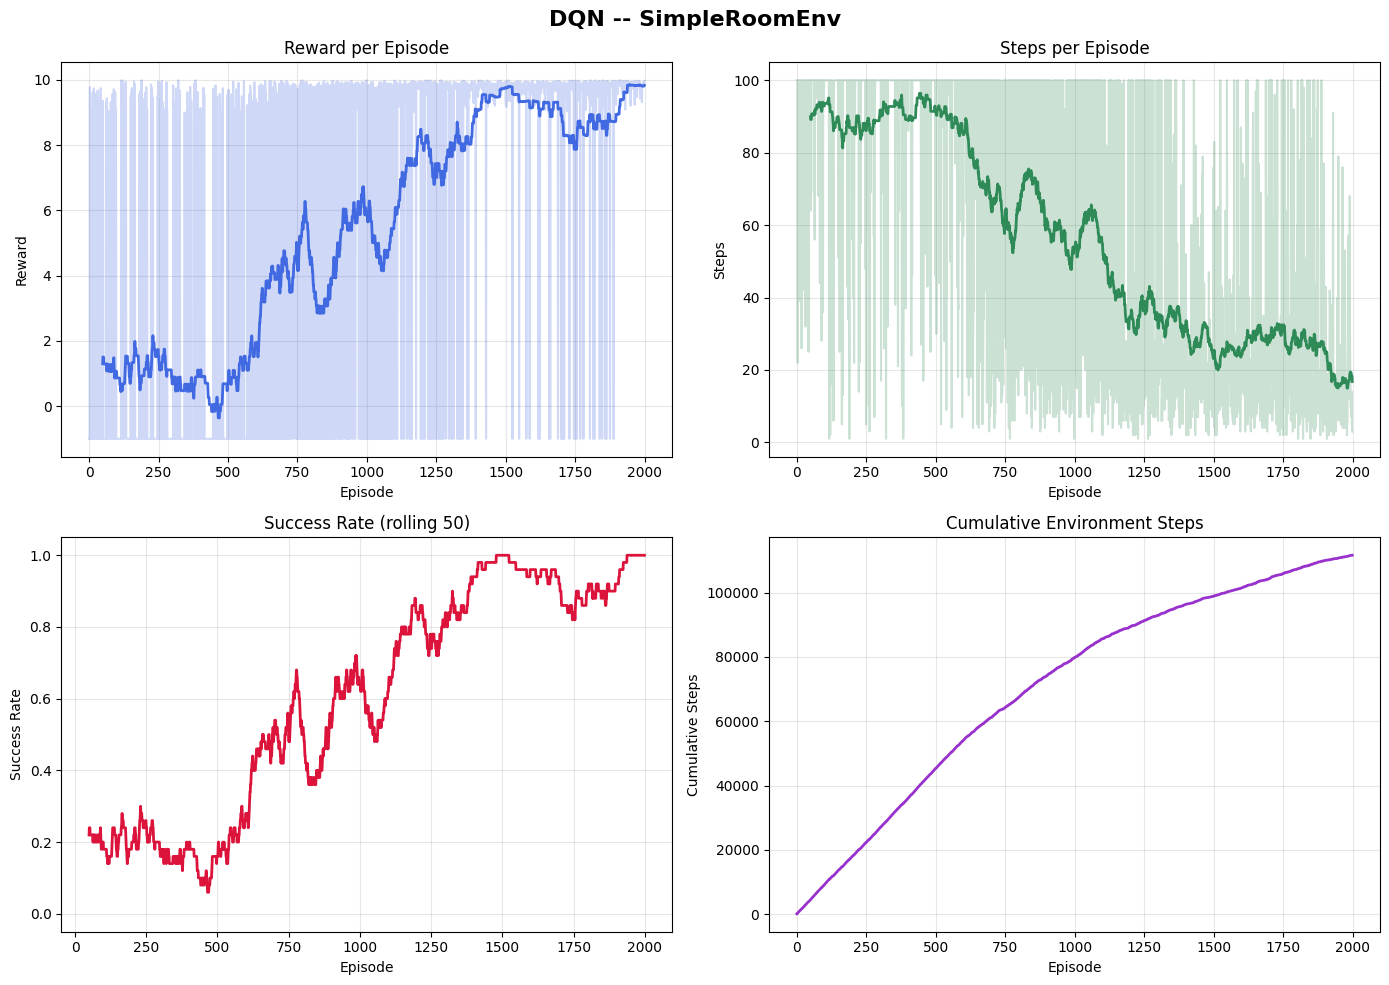

'/content/artifacts/plots/dqn_simple_training.png'

In [24]:
set_seed(42)
os.makedirs("videos", exist_ok=True)
print("Training DQN on SimpleRoomEnv ...")
t0 = time.time()
dqn_simple_agent, dqn_simple_log = train_dqn(
    make_simple_env, n_episodes=2000, seed=42,
    video_at={750: video_path("dqn_simple_mid750.mp4")},
    lr=1e-4, gamma=0.99,
    eps_start=1.0, eps_end=0.05, eps_decay_steps=120_000,
    buffer_size=30_000, batch_size=64, target_update=500, train_freq=4,
)
print(f"Done in {time.time()-t0:.0f}s -- final SR100={dqn_simple_log.get_success_rate(100):.3f}")

# --- persist results BEFORE plotting/eval ---
save_logger(dqn_simple_log, "dqn_simple")
save_agent(dqn_simple_agent, "dqn_simple")

# --- then plot / evaluate ---
fig = plot_training(dqn_simple_log, title="DQN -- SimpleRoomEnv")
save_figure(fig, "dqn_simple_training")

### REINFORCE on SimpleRoomEnv


Training REINFORCE on SimpleRoomEnv ...
  REINFORCE ep 100/3000  R=-1.00  steps=100  SR100=0.160
  REINFORCE ep 200/3000  R=+9.91  steps=9  SR100=0.200
  REINFORCE ep 300/3000  R=-1.00  steps=100  SR100=0.230
  REINFORCE ep 400/3000  R=+9.16  steps=84  SR100=0.210
  REINFORCE ep 500/3000  R=-1.00  steps=100  SR100=0.180
  REINFORCE ep 600/3000  R=-1.00  steps=100  SR100=0.160
  REINFORCE ep 700/3000  R=-1.00  steps=100  SR100=0.180
  REINFORCE ep 800/3000  R=+9.85  steps=15  SR100=0.180
  REINFORCE ep 900/3000  R=-1.00  steps=100  SR100=0.210
  REINFORCE ep 1000/3000  R=-1.00  steps=100  SR100=0.170
  REINFORCE ep 1100/3000  R=-1.00  steps=100  SR100=0.230
  REINFORCE ep 1200/3000  R=-1.00  steps=100  SR100=0.270
  REINFORCE ep 1300/3000  R=+9.70  steps=30  SR100=0.240
  REINFORCE ep 1400/3000  R=+9.59  steps=41  SR100=0.210
  REINFORCE ep 1500/3000  R=-1.00  steps=100  SR100=0.150
  >> Recorded mid-training video at ep 1500: /content/videos/reinforce_simple_mid1500.mp4 (R=-1.00)
  REI

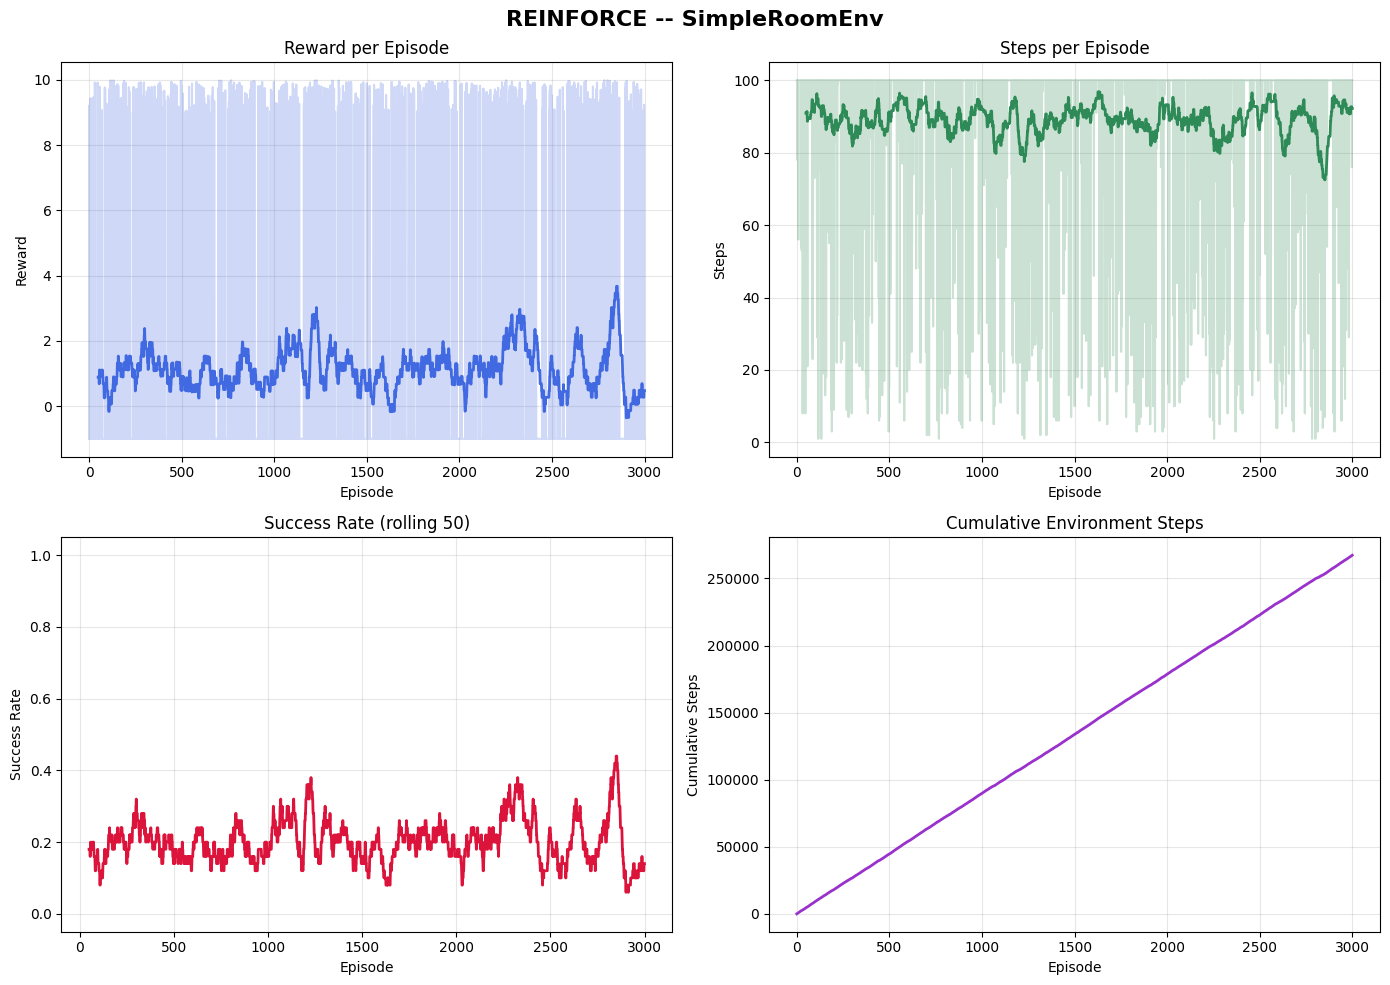

'/content/artifacts/plots/reinforce_simple_training.png'

In [ ]:
set_seed(42)
print("Training REINFORCE on SimpleRoomEnv ...")
t0 = time.time()
reinforce_simple_agent, reinforce_simple_log = train_reinforce(
    make_simple_env, n_episodes=3000, seed=42,
    video_at={1500: video_path("reinforce_simple_mid1500.mp4")},
    lr=5e-5, gamma=0.99, entropy_coef=0.001,
)
print(f"Done in {time.time()-t0:.0f}s -- final SR100={reinforce_simple_log.get_success_rate(100):.3f}")

# --- persist results BEFORE plotting/eval ---
save_logger(reinforce_simple_log, "reinforce_simple")
save_agent(reinforce_simple_agent, "reinforce_simple")

# --- then plot / evaluate ---
fig = plot_training(reinforce_simple_log, title="REINFORCE -- SimpleRoomEnv")
save_figure(fig, "reinforce_simple_training")

### PPO on SimpleRoomEnv


Training PPO on SimpleRoomEnv ...
  PPO ep 100/2500  shaped=-1.00  sparse=+0.00  steps=100  SR100=0.170
  PPO ep 200/2500  shaped=-1.00  sparse=+0.00  steps=100  SR100=0.400
  PPO ep 300/2500  shaped=+9.69  sparse=+1.00  steps=31  SR100=0.620
  PPO ep 400/2500  shaped=+9.10  sparse=+1.00  steps=90  SR100=0.610
  PPO ep 500/2500  shaped=-1.00  sparse=+0.00  steps=100  SR100=0.650
  PPO ep 600/2500  shaped=-1.00  sparse=+0.00  steps=100  SR100=0.620
  PPO ep 700/2500  shaped=-1.00  sparse=+0.00  steps=100  SR100=0.620
  PPO ep 800/2500  shaped=+9.11  sparse=+1.00  steps=89  SR100=0.580
  PPO ep 900/2500  shaped=+9.41  sparse=+1.00  steps=59  SR100=0.590
  PPO ep 1000/2500  shaped=-1.00  sparse=+0.00  steps=100  SR100=0.600
  PPO ep 1100/2500  shaped=+9.69  sparse=+1.00  steps=31  SR100=0.660
  PPO ep 1200/2500  shaped=+9.50  sparse=+1.00  steps=50  SR100=0.630
  >> Mid-training video ep 1250: /content/videos/ppo_simple_mid1250.mp4 (R=-1.00)
  PPO ep 1300/2500  shaped=+9.19  sparse=+1.00 

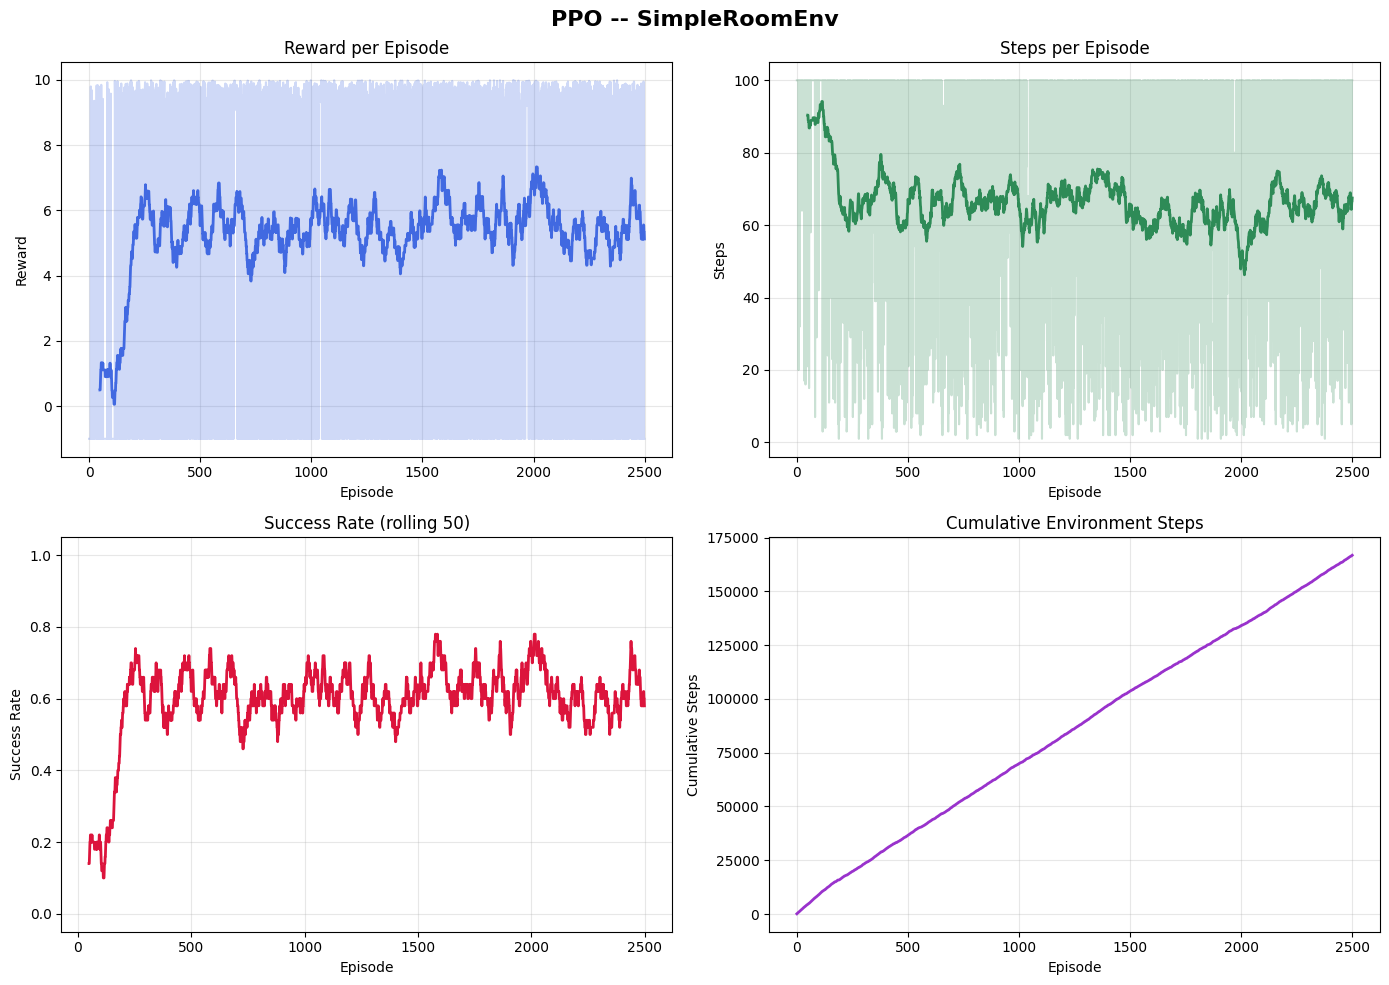

'/content/artifacts/plots/ppo_simple_training.png'

In [ ]:
set_seed(42)
print("Training PPO on SimpleRoomEnv ...")
t0 = time.time()
ppo_simple_agent, ppo_simple_log = train_ppo(
    make_simple_env, n_episodes=2500, seed=42,
    video_at={1250: video_path("ppo_simple_mid1250.mp4")},
    lr=1e-4, gamma=0.99, gae_lambda=0.95,
    clip_ratio=0.2, value_coef=0.5, entropy_coef=0.001,
    n_epochs=8, n_steps=512, target_kl=0.02,
)
print(f"Done in {time.time()-t0:.0f}s -- final SR100={ppo_simple_log.get_success_rate(100):.3f}")

# --- persist results BEFORE plotting/eval ---
save_logger(ppo_simple_log, "ppo_simple")
save_agent(ppo_simple_agent, "ppo_simple")

# --- then plot / evaluate ---
fig = plot_training(ppo_simple_log, title="PPO -- SimpleRoomEnv")
save_figure(fig, "ppo_simple_training")

### SimpleRoomEnv -- Algorithm Comparison


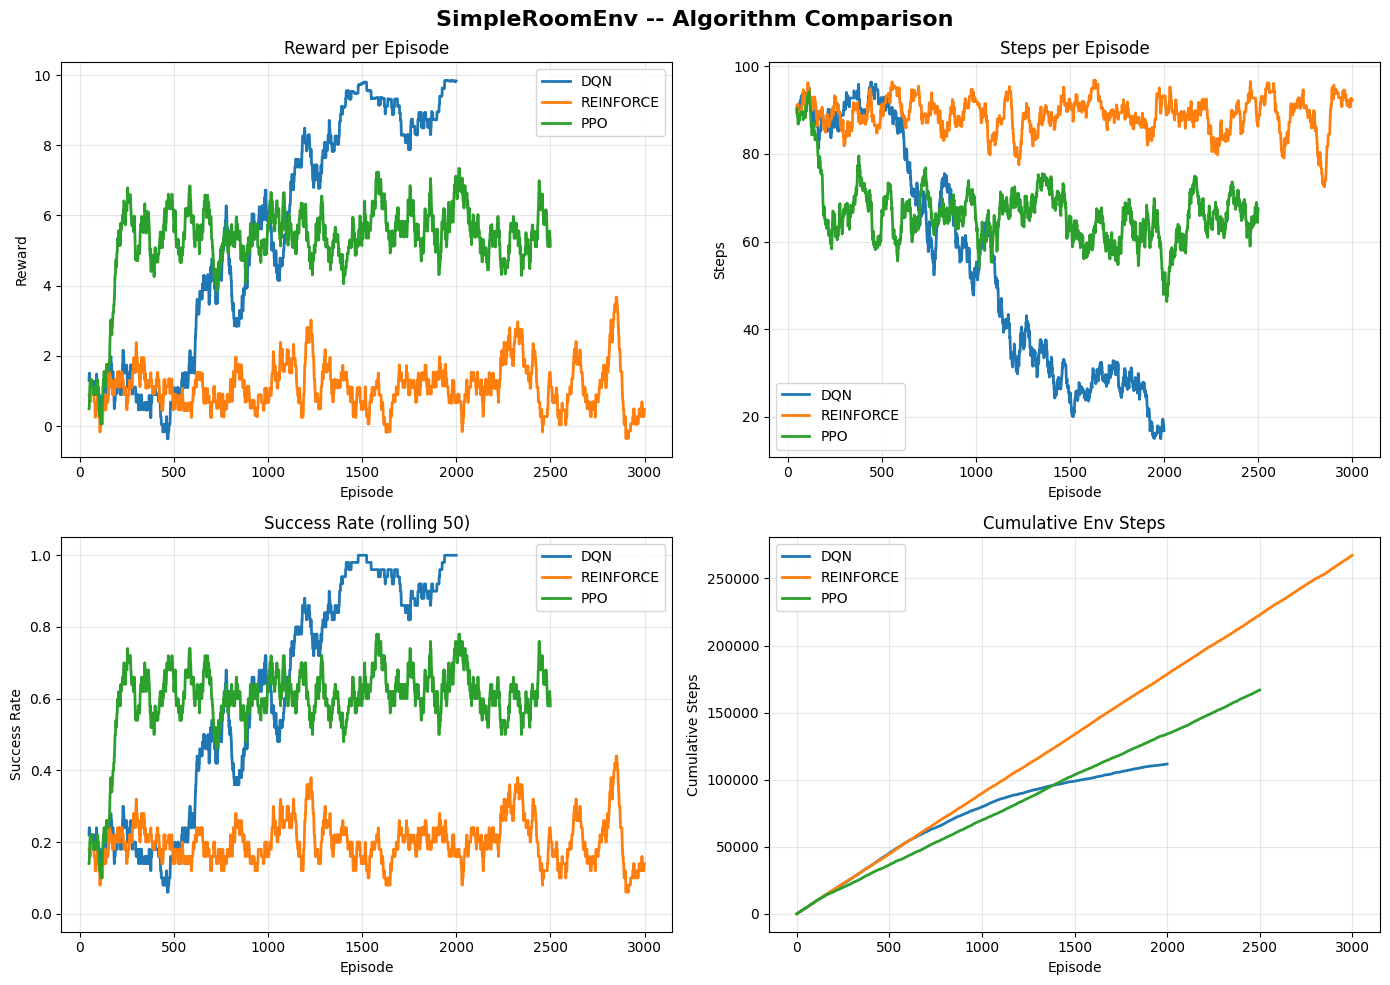

'/content/artifacts/plots/simple_comparison.png'

In [27]:
fig = plot_comparison(
    [dqn_simple_log, reinforce_simple_log, ppo_simple_log],
    ["DQN", "REINFORCE", "PPO"],
    title="SimpleRoomEnv -- Algorithm Comparison",
)
save_figure(fig, "simple_comparison")


### SimpleRoomEnv Evaluation — Greedy vs Sampled Policy Modes

In [28]:
# ============================================================
# SimpleRoomEnv evaluation: greedy + sampled policy modes
# ============================================================

simple_eval_results = {}

simple_eval_specs = [
    ("DQN", "greedy", dqn_simple_agent, make_simple_env),
    ("REINFORCE", "greedy", reinforce_simple_agent, make_simple_env),
    ("REINFORCE", "sample", reinforce_simple_agent, make_simple_env),
    ("PPO", "greedy", ppo_simple_agent, make_simple_env),
    ("PPO", "sample", ppo_simple_agent, make_simple_env),
]

for algo, mode, agent, factory in simple_eval_specs:
    print(f"Evaluating {algo} / SimpleRoomEnv / {mode} ...", end=" ")
    res = evaluate_agent_mode(factory, agent, n_episodes=50, mode=mode)
    simple_eval_results[(algo, mode)] = res

    print(
        f"SR={np.mean(res['successes']):.2f}  "
        f"sparse={np.mean(res['sparse_rewards']):.2f}  "
        f"shaped={np.mean(res['rewards']):.2f}  "
        f"steps={np.mean(res['steps']):.1f}"
    )

print("\n" + "=" * 95)
print(
    f"{'Algorithm':<12} {'Mode':<8} {'Env':<14} "
    f"{'Sparse':>10} {'Shaped':>10} {'Steps':>8} {'Success %':>10}"
)
print("-" * 95)

for (algo, mode), res in simple_eval_results.items():
    print(
        f"{algo:<12} {mode:<8} {'SimpleRoom':<14} "
        f"{np.mean(res['sparse_rewards']):>+10.3f} "
        f"{np.mean(res['rewards']):>+10.2f} "
        f"{np.mean(res['steps']):>8.1f} "
        f"{100 * np.mean(res['successes']):>9.1f}%"
    )

print("=" * 95)

import json as _json

simple_eval_dump = {
    f"{algo}_{mode}": {kk: vv for kk, vv in res.items() if kk != "infos"}
    for (algo, mode), res in simple_eval_results.items()
}

with open(os.path.join(ARTIFACTS, "logs", "simple_eval_results_modes.json"), "w") as f:
    _json.dump(simple_eval_dump, f, indent=2)

print("Saved simple_eval_results_modes.json")

Evaluating DQN / SimpleRoomEnv / greedy ... SR=0.90  sparse=0.90  shaped=8.81  steps=19.3
Evaluating REINFORCE / SimpleRoomEnv / greedy ... SR=0.06  sparse=0.06  shaped=-0.34  steps=94.4
Evaluating REINFORCE / SimpleRoomEnv / sample ... SR=0.26  sparse=0.26  shaped=1.73  steps=87.1
Evaluating PPO / SimpleRoomEnv / greedy ... SR=0.02  sparse=0.02  shaped=-0.78  steps=98.1
Evaluating PPO / SimpleRoomEnv / sample ... SR=0.56  sparse=0.56  shaped=4.93  steps=66.7

Algorithm    Mode     Env                Sparse     Shaped    Steps  Success %
-----------------------------------------------------------------------------------------------
DQN          greedy   SimpleRoom         +0.900      +8.81     19.3      90.0%
REINFORCE    greedy   SimpleRoom         +0.060      -0.34     94.4       6.0%
REINFORCE    sample   SimpleRoom         +0.260      +1.73     87.1      26.0%
PPO          greedy   SimpleRoom         +0.020      -0.78     98.1       2.0%
PPO          sample   SimpleRoom         +0.

In [29]:
# ============================================================
# Policy confidence diagnostic
# ============================================================

def policy_confidence(agent, env_factory, n_episodes=10, seed=42):
    """Print mean max action probability and entropy for a policy agent."""
    max_probs = []
    entropies = []

    for ep in range(n_episodes):
        env = env_factory()
        obs, info = env.reset(seed=episode_seed(seed, ep, "eval"))

        while True:
            t = torch.as_tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)

            with torch.no_grad():
                if hasattr(agent, "policy"):
                    logits = agent.policy(t)
                elif hasattr(agent, "network"):
                    logits, _ = agent.network(t)
                else:
                    raise ValueError("policy_confidence is only for policy agents")

                probs = torch.softmax(logits, dim=-1)
                dist = torch.distributions.Categorical(probs=probs)

                max_probs.append(float(probs.max().item()))
                entropies.append(float(dist.entropy().item()))

                action = int(probs.argmax(1).item())

            obs, reward, terminated, truncated, info = env.step(action)
            if terminated or truncated:
                break

        env.close()

    print(f"Mean max prob: {np.mean(max_probs):.3f}")
    print(f"Mean entropy : {np.mean(entropies):.3f}")

In [30]:
print("REINFORCE confidence:")
policy_confidence(reinforce_simple_agent, make_simple_env)

print("\nPPO confidence:")
policy_confidence(ppo_simple_agent, make_simple_env)

REINFORCE confidence:
Mean max prob: 0.334
Mean entropy : 1.099

PPO confidence:
Mean max prob: 0.849
Mean entropy : 0.428


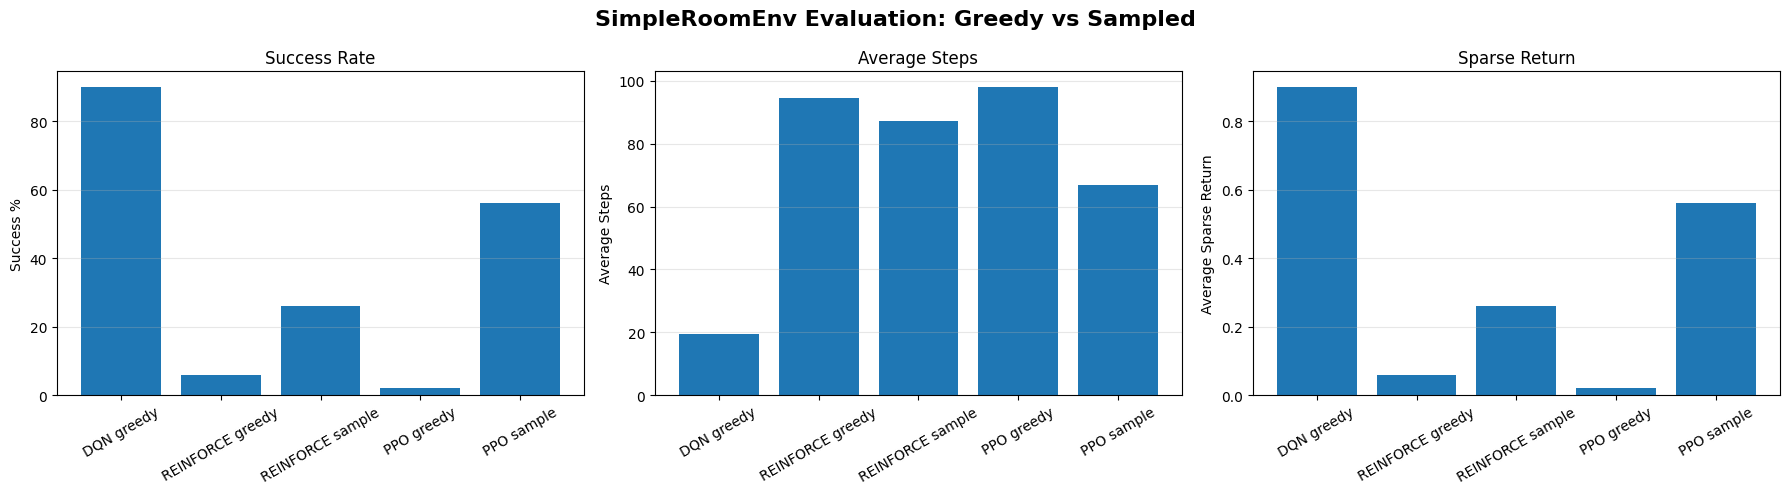

In [31]:
# ============================================================
# SimpleRoomEnv mode-aware inference chart
# ============================================================

labels = ["DQN greedy", "REINFORCE greedy", "REINFORCE sample", "PPO greedy", "PPO sample"]
keys = [
    ("DQN", "greedy"),
    ("REINFORCE", "greedy"),
    ("REINFORCE", "sample"),
    ("PPO", "greedy"),
    ("PPO", "sample"),
]

success_vals = [100*np.mean(simple_eval_results[k]["successes"]) for k in keys]
step_vals = [np.mean(simple_eval_results[k]["steps"]) for k in keys]
sparse_vals = [np.mean(simple_eval_results[k]["sparse_rewards"]) for k in keys]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("SimpleRoomEnv Evaluation: Greedy vs Sampled", fontsize=16, fontweight="bold")

axes[0].bar(labels, success_vals)
axes[0].set(ylabel="Success %", title="Success Rate")
axes[0].tick_params(axis="x", rotation=30)
axes[0].grid(True, alpha=0.3, axis="y")

axes[1].bar(labels, step_vals)
axes[1].set(ylabel="Average Steps", title="Average Steps")
axes[1].tick_params(axis="x", rotation=30)
axes[1].grid(True, alpha=0.3, axis="y")

axes[2].bar(labels, sparse_vals)
axes[2].set(ylabel="Average Sparse Return", title="Sparse Return")
axes[2].tick_params(axis="x", rotation=30)
axes[2].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
save_figure(fig, "simple_eval_greedy_vs_sample")
plt.show()

# Training -- ComplexEnv

The hard task: key -> door -> water -> lava -> goal.  Partial progress is expected
and analysed via the 5-stage breakdown.

- **Observation:** colour (3, 84, 84)
- **Actions:** left / right / forward / pickup / drop / toggle (Discrete(6))
- **Shaping:** milestone bonuses, step penalty 0.01, lava-death penalty 2.0


### DQN on ComplexEnv


Training DQN on ComplexEnv ...
  DQN ep 100/3000  R=-3.00  steps=400  eps=0.955  SR100=0.000
  DQN ep 200/3000  R=-3.00  steps=400  eps=0.910  SR100=0.000
  DQN ep 300/3000  R=-3.00  steps=400  eps=0.866  SR100=0.000
  DQN ep 400/3000  R=-3.00  steps=400  eps=0.821  SR100=0.000
  DQN ep 500/3000  R=-1.00  steps=400  eps=0.776  SR100=0.000
  DQN ep 600/3000  R=-0.50  steps=400  eps=0.732  SR100=0.000
  DQN ep 700/3000  R=+0.00  steps=400  eps=0.689  SR100=0.000
  DQN ep 800/3000  R=-3.00  steps=400  eps=0.644  SR100=0.000
  DQN ep 900/3000  R=-0.50  steps=400  eps=0.600  SR100=0.000
  DQN ep 1000/3000  R=+0.00  steps=400  eps=0.560  SR100=0.000
  DQN ep 1100/3000  R=-3.00  steps=400  eps=0.518  SR100=0.000
  DQN ep 1200/3000  R=-3.00  steps=400  eps=0.476  SR100=0.010
  DQN ep 1300/3000  R=-3.00  steps=400  eps=0.440  SR100=0.030
  DQN ep 1400/3000  R=-1.00  steps=400  eps=0.405  SR100=0.060
  DQN ep 1500/3000  R=-0.00  steps=400  eps=0.365  SR100=0.030
  >> Recorded mid-training video 

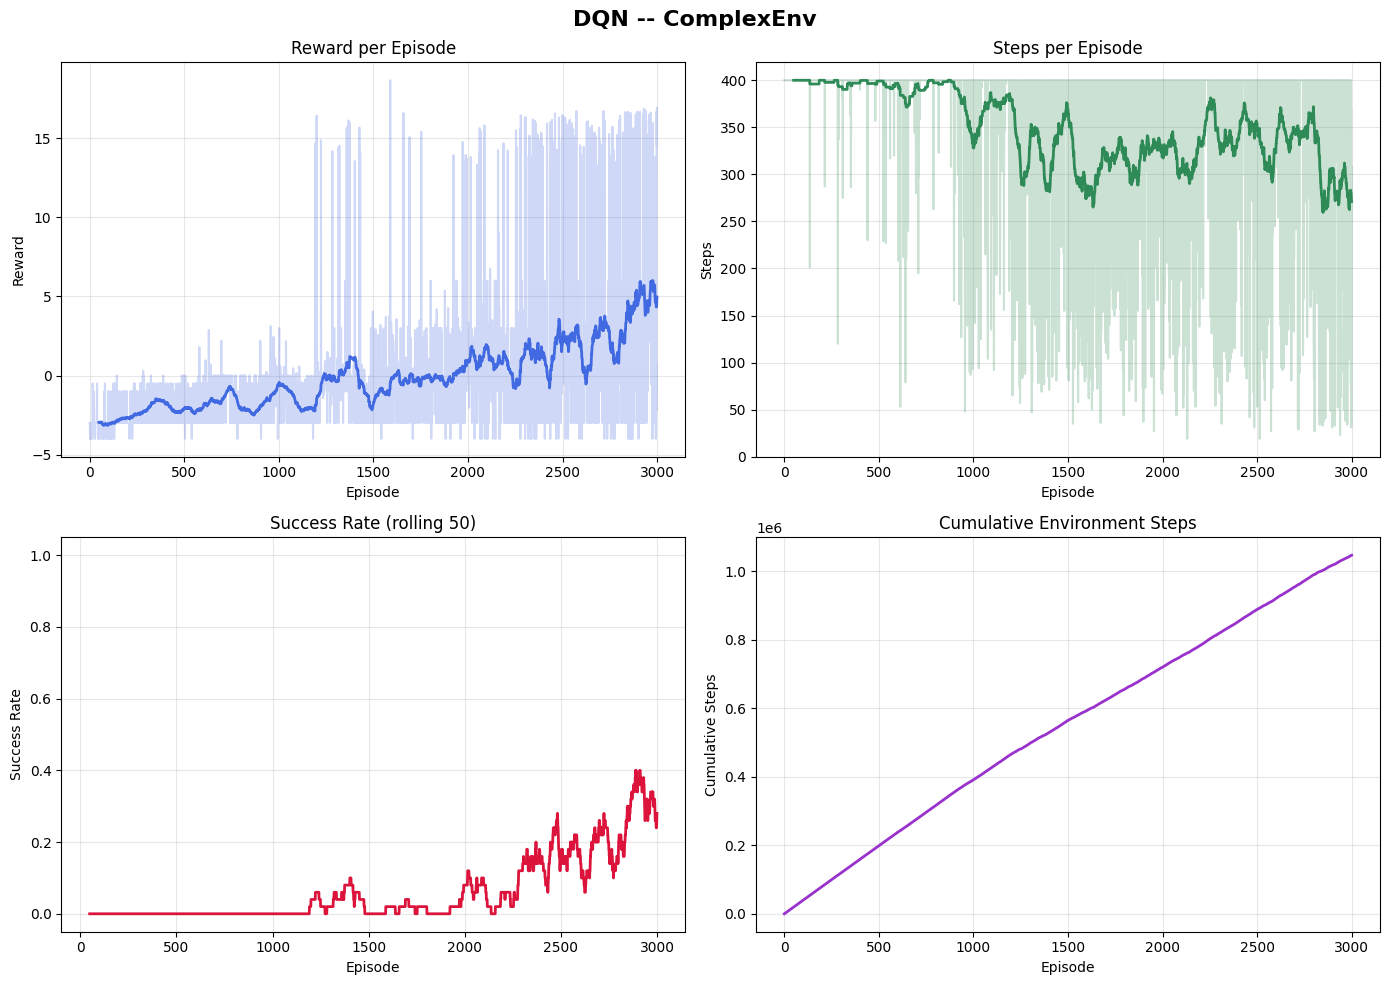

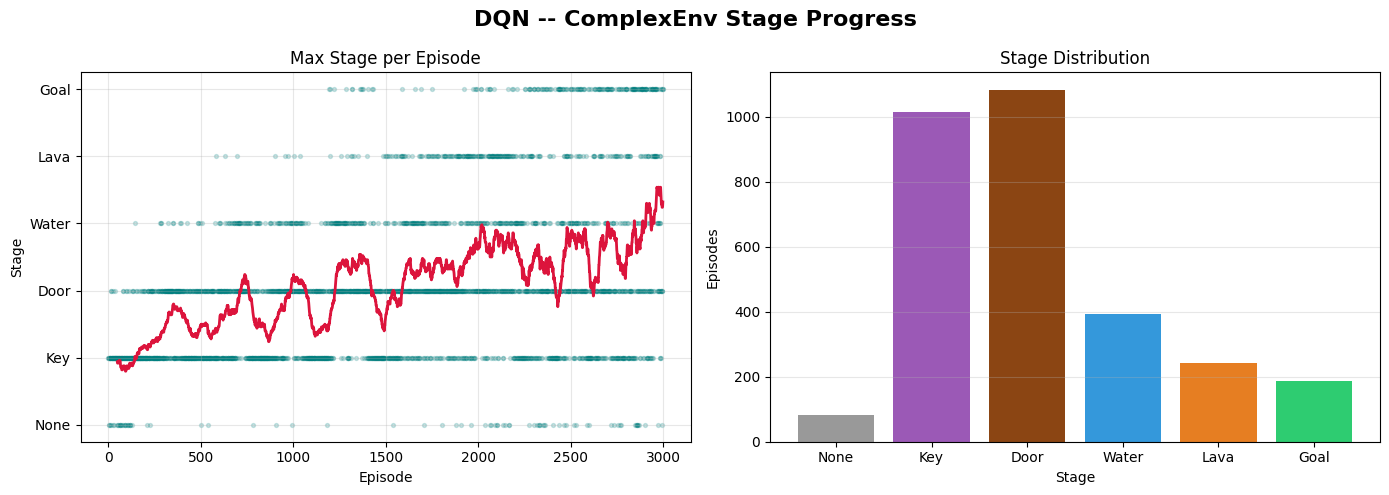

'/content/artifacts/plots/dqn_complex_stage_progress.png'

In [32]:
set_seed(42)
print("Training DQN on ComplexEnv ...")
t0 = time.time()
dqn_complex_agent, dqn_complex_log = train_dqn(
    make_complex_env, n_episodes=3000, seed=42,
    video_at={1500: video_path("dqn_complex_mid1500.mp4")},
    lr=1e-4, gamma=0.99,
    eps_start=1.0, eps_end=0.10, eps_decay_steps=800_000,
    buffer_size=100_000, batch_size=64, target_update=1000, train_freq=4,
)
print(f"Done in {time.time()-t0:.0f}s -- final SR100={dqn_complex_log.get_success_rate(100):.3f}")

# --- persist results BEFORE plotting/eval ---
save_logger(dqn_complex_log, "dqn_complex")
save_agent(dqn_complex_agent, "dqn_complex")

# --- then plot / evaluate ---
fig = plot_training(dqn_complex_log, title="DQN -- ComplexEnv")
save_figure(fig, "dqn_complex_training")

fig = plot_stage_progress(dqn_complex_log, title="DQN -- ComplexEnv Stage Progress")
save_figure(fig, "dqn_complex_stage_progress")

### REINFORCE on ComplexEnv


Training REINFORCE on ComplexEnv ...
  REINFORCE ep 100/3000  R=-4.00  steps=400  SR100=0.000
  REINFORCE ep 200/3000  R=-3.00  steps=400  SR100=0.000
  REINFORCE ep 300/3000  R=-3.00  steps=400  SR100=0.000
  REINFORCE ep 400/3000  R=-3.00  steps=400  SR100=0.000
  REINFORCE ep 500/3000  R=-3.00  steps=400  SR100=0.000
  REINFORCE ep 600/3000  R=-4.00  steps=400  SR100=0.000
  REINFORCE ep 700/3000  R=-1.00  steps=400  SR100=0.000
  REINFORCE ep 800/3000  R=-3.00  steps=400  SR100=0.000
  REINFORCE ep 900/3000  R=-3.00  steps=400  SR100=0.000
  REINFORCE ep 1000/3000  R=-3.00  steps=400  SR100=0.000
  REINFORCE ep 1100/3000  R=-3.00  steps=400  SR100=0.000
  REINFORCE ep 1200/3000  R=-3.00  steps=400  SR100=0.000
  REINFORCE ep 1300/3000  R=-3.00  steps=400  SR100=0.000
  REINFORCE ep 1400/3000  R=-3.00  steps=400  SR100=0.000
  REINFORCE ep 1500/3000  R=-3.00  steps=400  SR100=0.000
  >> Recorded mid-training video at ep 1500: /content/videos/reinforce_complex_mid1500.mp4 (R=-4.00)
 

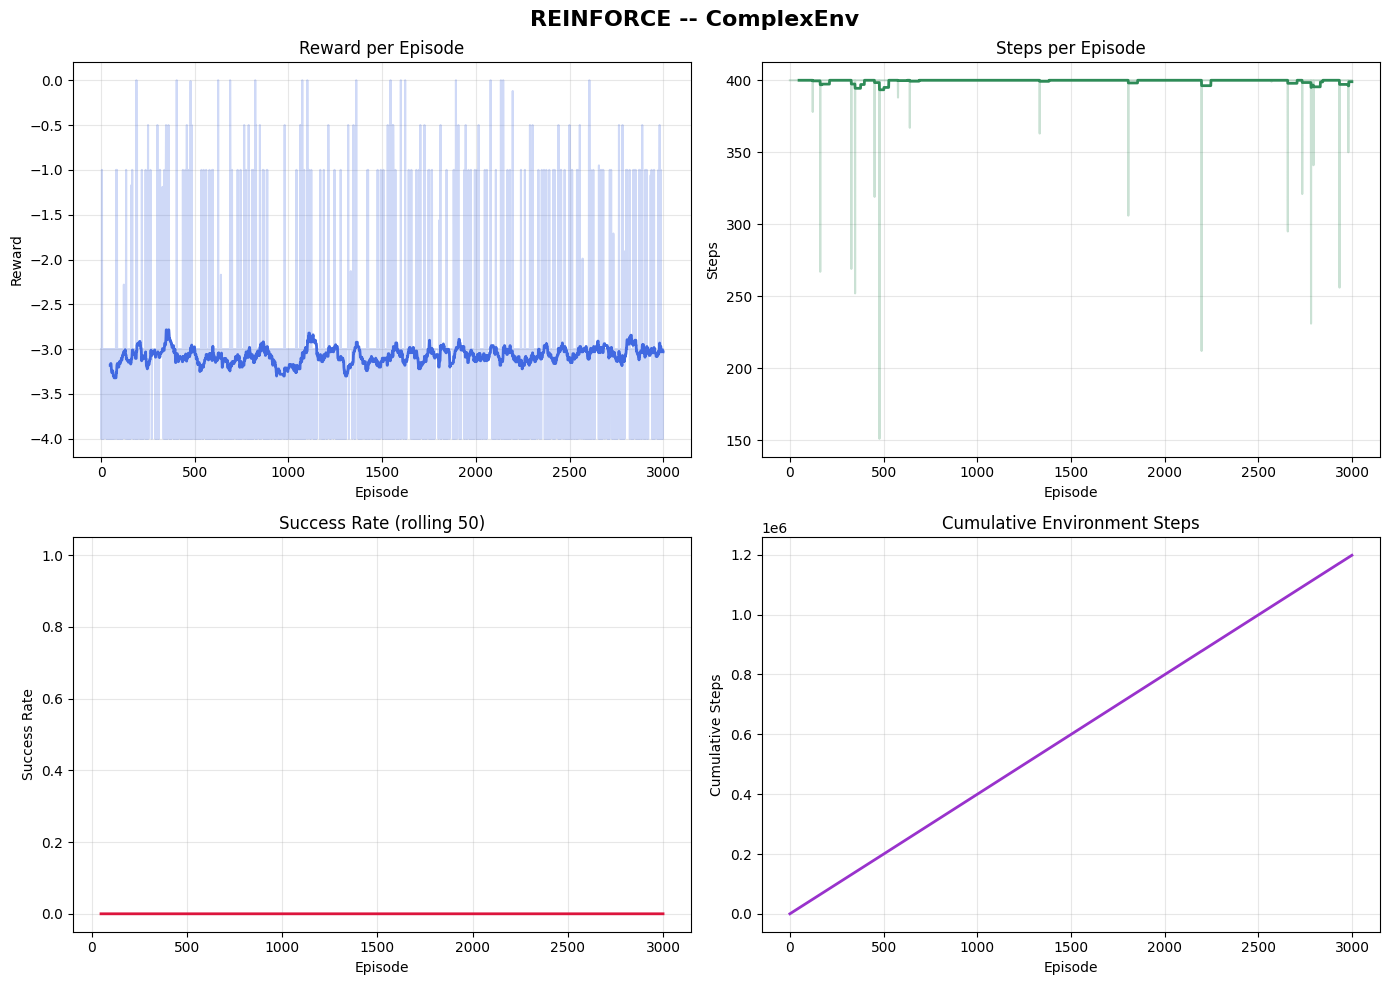

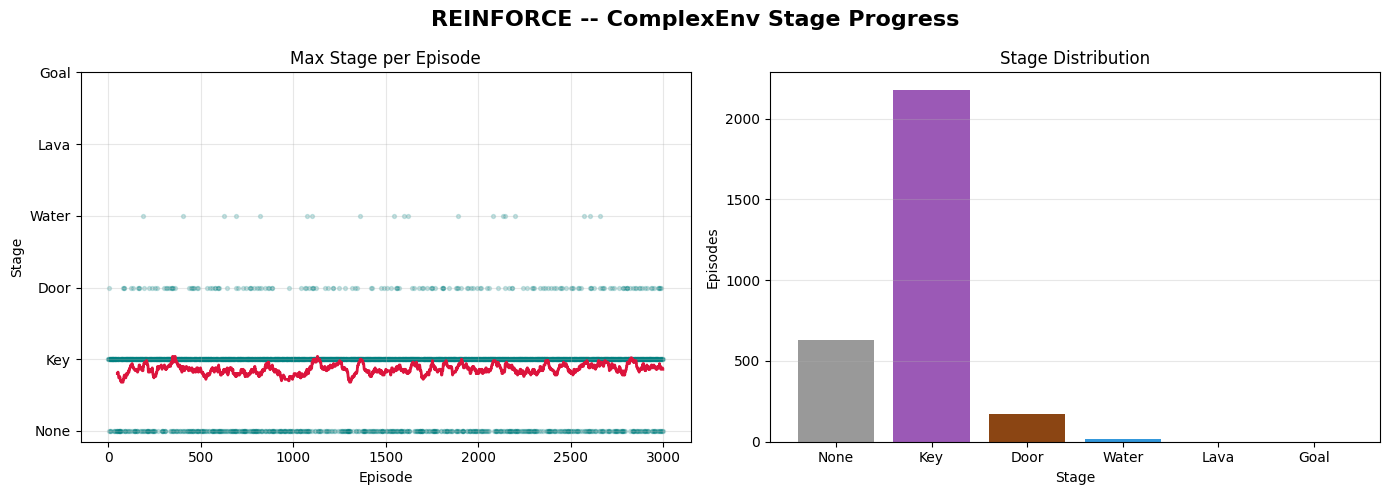

'/content/artifacts/plots/reinforce_complex_stage_progress.png'

In [33]:
set_seed(42)
print("Training REINFORCE on ComplexEnv ...")
t0 = time.time()
reinforce_complex_agent, reinforce_complex_log = train_reinforce(
    make_complex_env, n_episodes=3000, seed=42,
    video_at={1500: video_path("reinforce_complex_mid1500.mp4")},
    lr=5e-5, gamma=0.99, entropy_coef=0.02,
    value_coef=0.5,
)
print(f"Done in {time.time()-t0:.0f}s -- final SR100={reinforce_complex_log.get_success_rate(100):.3f}")

# --- persist results BEFORE plotting/eval ---
save_logger(reinforce_complex_log, "reinforce_complex")
save_agent(reinforce_complex_agent, "reinforce_complex")

# --- then plot / evaluate ---
fig = plot_training(reinforce_complex_log, title="REINFORCE -- ComplexEnv")
save_figure(fig, "reinforce_complex_training")

fig = plot_stage_progress(reinforce_complex_log, title="REINFORCE -- ComplexEnv Stage Progress")
save_figure(fig, "reinforce_complex_stage_progress")

### PPO on ComplexEnv


Training PPO on ComplexEnv ...
  PPO ep 100/3000  shaped=-3.00  sparse=+0.00  steps=400  SR100=0.000
  PPO ep 200/3000  shaped=-3.00  sparse=+0.00  steps=400  SR100=0.000
  PPO ep 300/3000  shaped=-2.43  sparse=+0.00  steps=393  SR100=0.000
  PPO ep 400/3000  shaped=-0.75  sparse=+0.00  steps=225  SR100=0.000
  PPO ep 500/3000  shaped=-4.00  sparse=+0.00  steps=400  SR100=0.000
  PPO ep 600/3000  shaped=-3.00  sparse=+0.00  steps=400  SR100=0.000
  PPO ep 700/3000  shaped=-3.00  sparse=+0.00  steps=400  SR100=0.000
  PPO ep 800/3000  shaped=-3.00  sparse=+0.00  steps=400  SR100=0.000
  PPO ep 900/3000  shaped=-3.00  sparse=+0.00  steps=400  SR100=0.000
  PPO ep 1000/3000  shaped=-2.11  sparse=+0.00  steps=361  SR100=0.000
  PPO ep 1100/3000  shaped=-3.00  sparse=+0.00  steps=400  SR100=0.000
  PPO ep 1200/3000  shaped=-4.00  sparse=+0.00  steps=400  SR100=0.000
  PPO ep 1300/3000  shaped=-4.00  sparse=+0.00  steps=400  SR100=0.000
  PPO ep 1400/3000  shaped=-3.00  sparse=+0.00  steps=4

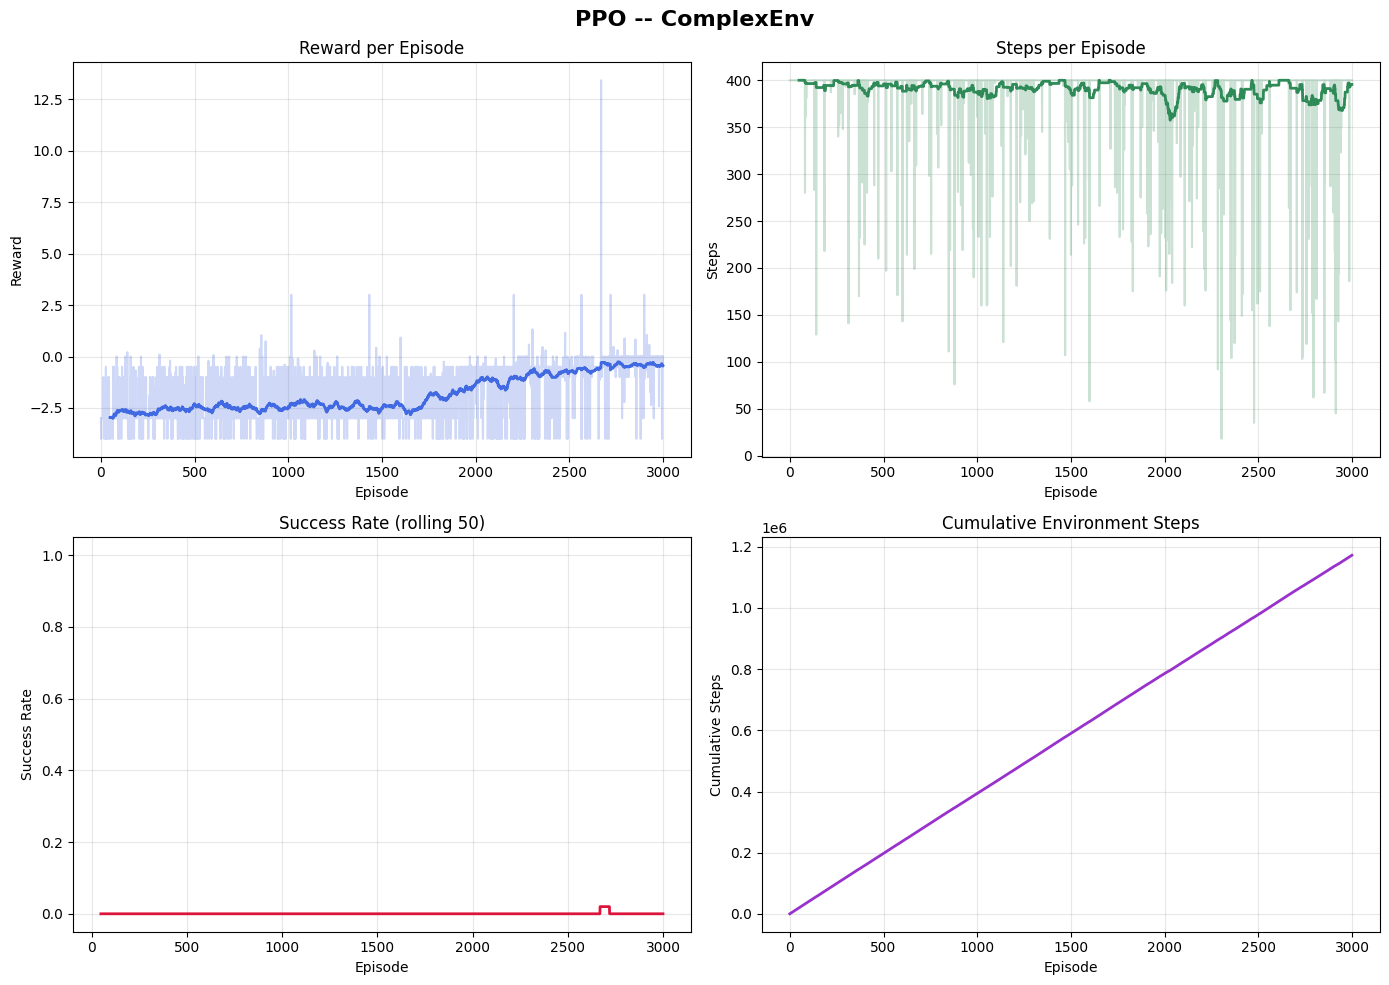

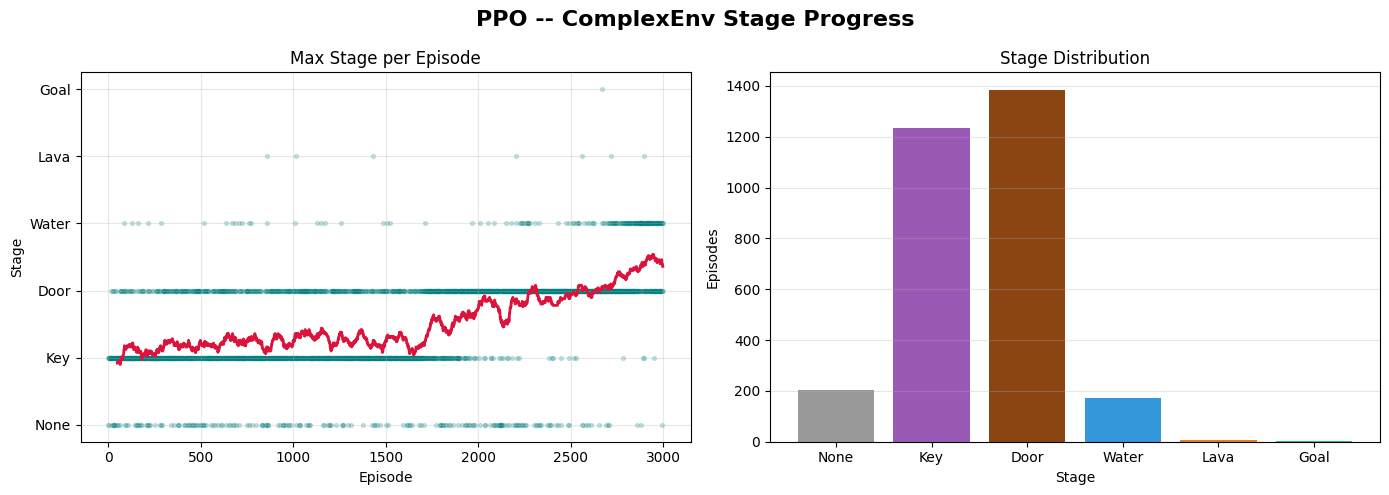

'/content/artifacts/plots/ppo_complex_stage_progress.png'

In [34]:
set_seed(42)
print("Training PPO on ComplexEnv ...")
t0 = time.time()
ppo_complex_agent, ppo_complex_log = train_ppo(
    make_complex_env, n_episodes=3000, seed=42,
    video_at={1500: video_path("ppo_complex_mid1500.mp4")},
    lr=1e-4, gamma=0.99, gae_lambda=0.95,
    clip_ratio=0.2, value_coef=0.5, entropy_coef=0.01,
    n_epochs=6, n_steps=1024, target_kl=0.03,
)
print(f"Done in {time.time()-t0:.0f}s -- final SR100={ppo_complex_log.get_success_rate(100):.3f}")

# --- persist results BEFORE plotting/eval ---
save_logger(ppo_complex_log, "ppo_complex")
save_agent(ppo_complex_agent, "ppo_complex")

# --- then plot / evaluate ---
fig = plot_training(ppo_complex_log, title="PPO -- ComplexEnv")
save_figure(fig, "ppo_complex_training")

fig = plot_stage_progress(ppo_complex_log, title="PPO -- ComplexEnv Stage Progress")
save_figure(fig, "ppo_complex_stage_progress")

### ComplexEnv -- Algorithm Comparison


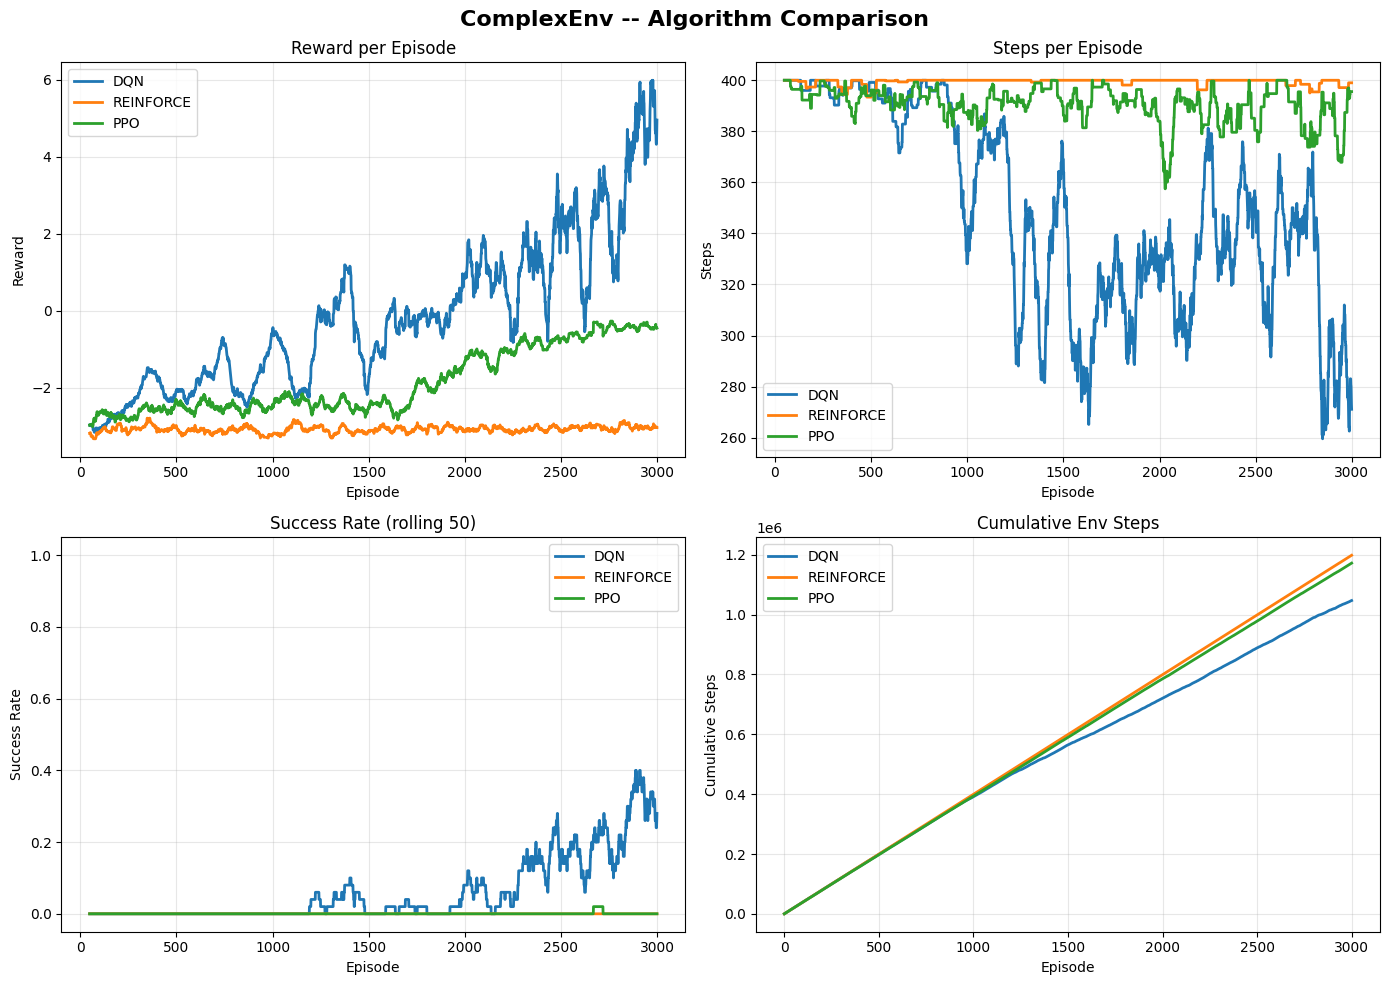

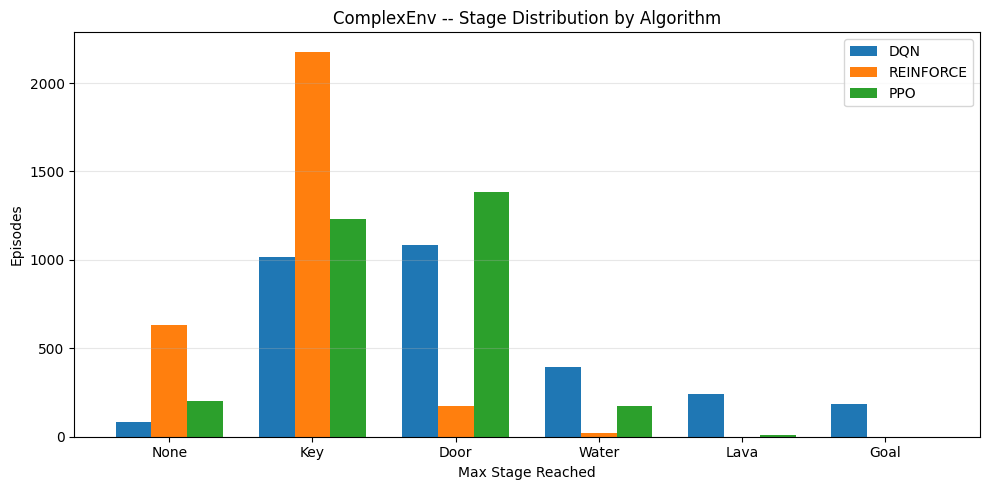

In [35]:
fig = plot_comparison(
    [dqn_complex_log, reinforce_complex_log, ppo_complex_log],
    ["DQN", "REINFORCE", "PPO"],
    title="ComplexEnv -- Algorithm Comparison",
)
save_figure(fig, "complex_comparison")

# Stage comparison bar chart
fig, ax = plt.subplots(figsize=(10, 5))
stage_labels = ["None", "Key", "Door", "Water", "Lava", "Goal"]
width = 0.25
x = np.arange(6)
for i, (lg, name) in enumerate(zip(
    [dqn_complex_log, reinforce_complex_log, ppo_complex_log],
    ["DQN", "REINFORCE", "PPO"])):
    counts = [lg.stages.count(s) for s in range(6)] if lg.stages else [0]*6
    ax.bar(x + i * width, counts, width, label=name)
ax.set_xticks(x + width)
ax.set_xticklabels(stage_labels)
ax.set(xlabel="Max Stage Reached", ylabel="Episodes",
       title="ComplexEnv -- Stage Distribution by Algorithm")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
save_figure(fig, "complex_training_stage_bar")
plt.show()


### ComplexEnv Evaluation — Greedy vs Sampled Policy Modes

In [36]:
# ============================================================
# ComplexEnv evaluation: greedy + sampled policy modes
# ============================================================

complex_eval_results = {}

complex_eval_specs = [
    ("DQN", "greedy", dqn_complex_agent, make_complex_env),
    ("REINFORCE", "greedy", reinforce_complex_agent, make_complex_env),
    ("REINFORCE", "sample", reinforce_complex_agent, make_complex_env),
    ("PPO", "greedy", ppo_complex_agent, make_complex_env),
    ("PPO", "sample", ppo_complex_agent, make_complex_env),
]

for algo, mode, agent, factory in complex_eval_specs:
    print(f"Evaluating {algo} / ComplexEnv / {mode} ...", end=" ")
    res = evaluate_agent_mode(factory, agent, n_episodes=50, mode=mode)
    complex_eval_results[(algo, mode)] = res

    print(
        f"SR={np.mean(res['successes']):.2f}  "
        f"sparse={np.mean(res['sparse_rewards']):.2f}  "
        f"shaped={np.mean(res['rewards']):.2f}  "
        f"steps={np.mean(res['steps']):.1f}  "
        f"max_stage={max(res['stages']) if res['stages'] else 0}  "
        f"lava_death={100 * np.mean(res['lava_deaths']):.1f}%  "
        f"ext={np.mean(res['extinguished']):.2f}"
    )

print("\n" + "=" * 120)
print(
    f"{'Algorithm':<12} {'Mode':<8} {'Env':<10} "
    f"{'Sparse':>10} {'Shaped':>10} {'Steps':>8} {'Success %':>10} "
    f"{'MaxStage':>9} {'LavaDeath %':>12} {'Avg Ext.':>10}"
)
print("-" * 120)

for (algo, mode), res in complex_eval_results.items():
    print(
        f"{algo:<12} {mode:<8} {'Complex':<10} "
        f"{np.mean(res['sparse_rewards']):>+10.3f} "
        f"{np.mean(res['rewards']):>+10.2f} "
        f"{np.mean(res['steps']):>8.1f} "
        f"{100 * np.mean(res['successes']):>9.1f}% "
        f"{max(res['stages']) if res['stages'] else 0:>9} "
        f"{100 * np.mean(res['lava_deaths']):>11.1f}% "
        f"{np.mean(res['extinguished']):>10.2f}"
    )

print("=" * 120)

import json as _json

complex_eval_dump = {
    f"{algo}_{mode}": {kk: vv for kk, vv in res.items() if kk != "infos"}
    for (algo, mode), res in complex_eval_results.items()
}

with open(os.path.join(ARTIFACTS, "logs", "complex_eval_results_modes.json"), "w") as f:
    _json.dump(complex_eval_dump, f, indent=2)

print("Saved complex_eval_results_modes.json")

Evaluating DQN / ComplexEnv / greedy ... SR=0.02  sparse=0.02  shaped=-2.60  steps=392.6  max_stage=5  lava_death=0.0%  ext=0.04
Evaluating REINFORCE / ComplexEnv / greedy ... SR=0.00  sparse=0.00  shaped=-3.98  steps=400.0  max_stage=1  lava_death=0.0%  ext=0.00
Evaluating REINFORCE / ComplexEnv / sample ... SR=0.00  sparse=0.00  shaped=-3.15  steps=400.0  max_stage=2  lava_death=0.0%  ext=0.00
Evaluating PPO / ComplexEnv / greedy ... SR=0.00  sparse=0.00  shaped=-3.88  steps=400.0  max_stage=1  lava_death=0.0%  ext=0.00
Evaluating PPO / ComplexEnv / sample ... SR=0.00  sparse=0.00  shaped=-0.37  steps=395.5  max_stage=3  lava_death=4.0%  ext=0.00

Algorithm    Mode     Env            Sparse     Shaped    Steps  Success %  MaxStage  LavaDeath %   Avg Ext.
------------------------------------------------------------------------------------------------------------------------
DQN          greedy   Complex        +0.020      -2.60    392.6       2.0%         5         0.0%       0.04
REI

In [37]:
# ============================================================
# ComplexEnv -- Evaluation Stage Breakdown (50 episodes)
# ============================================================

print("\n" + "=" * 100)
print("ComplexEnv -- Evaluation Stage Breakdown (50 episodes)")
print("-" * 100)

stage_labels = ["None", "Key", "Door", "Water", "Lava", "Goal"]

for key in [
    ("DQN", "greedy"),
    ("REINFORCE", "greedy"),
    ("REINFORCE", "sample"),
    ("PPO", "greedy"),
    ("PPO", "sample"),
]:
    algo, mode = key
    res = complex_eval_results[key]

    if "stages" in res and len(res["stages"]) > 0:
        stages = [int(s) for s in res["stages"]]
    else:
        stages = [int(info.get("stage_reached", 0)) for info in res["infos"]]

    counts = {s: stages.count(s) for s in range(6)}
    dist_str = "  ".join(
        f"{stage_labels[s]}:{counts[s]}" for s in range(6)
    )

    print(f"  {algo:<12} {mode:<8} {dist_str}")

print("=" * 100)


ComplexEnv -- Evaluation Stage Breakdown (50 episodes)
----------------------------------------------------------------------------------------------------
  DQN          greedy   None:26  Key:14  Door:7  Water:1  Lava:1  Goal:1
  REINFORCE    greedy   None:49  Key:1  Door:0  Water:0  Lava:0  Goal:0
  REINFORCE    sample   None:12  Key:36  Door:2  Water:0  Lava:0  Goal:0
  PPO          greedy   None:44  Key:6  Door:0  Water:0  Lava:0  Goal:0
  PPO          sample   None:0  Key:1  Door:25  Water:24  Lava:0  Goal:0


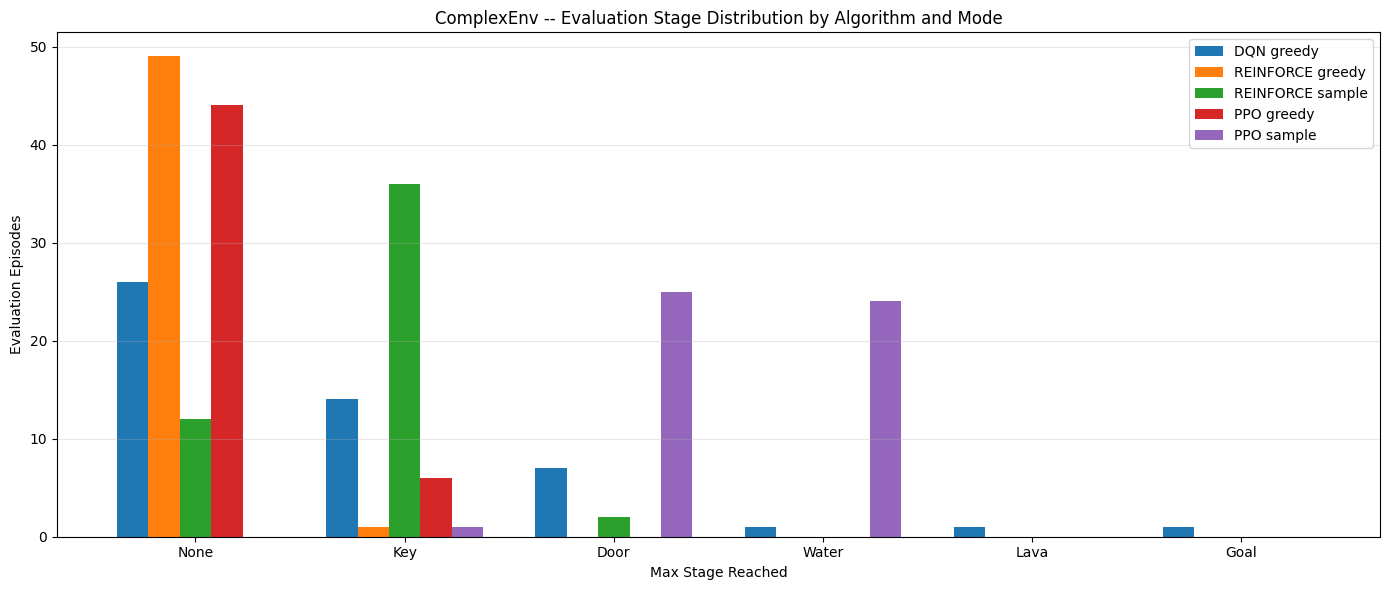

In [38]:
# ============================================================
# ComplexEnv -- Evaluation Stage Distribution Grouped Bar Chart
# ============================================================

stage_labels = ["None", "Key", "Door", "Water", "Lava", "Goal"]

eval_stage_keys = [
    ("DQN", "greedy"),
    ("REINFORCE", "greedy"),
    ("REINFORCE", "sample"),
    ("PPO", "greedy"),
    ("PPO", "sample"),
]

eval_stage_names = [
    "DQN greedy",
    "REINFORCE greedy",
    "REINFORCE sample",
    "PPO greedy",
    "PPO sample",
]

stage_counts = []

for key in eval_stage_keys:
    res = complex_eval_results[key]

    if "stages" in res and len(res["stages"]) > 0:
        stages = [int(s) for s in res["stages"]]
    else:
        stages = [int(info.get("stage_reached", 0)) for info in res["infos"]]

    counts = [stages.count(s) for s in range(6)]
    stage_counts.append(counts)

stage_counts = np.array(stage_counts)

fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(stage_labels))
width = 0.15

for i, name in enumerate(eval_stage_names):
    ax.bar(
        x + (i - 2) * width,
        stage_counts[i],
        width,
        label=name,
    )

ax.set_xticks(x)
ax.set_xticklabels(stage_labels)
ax.set(
    xlabel="Max Stage Reached",
    ylabel="Evaluation Episodes",
    title="ComplexEnv -- Evaluation Stage Distribution by Algorithm and Mode",
)
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
save_figure(fig, "complex_eval_stage_bar_modes")
plt.show()

# Video Clips

Short clips of each agent at **two points in training**:
1. **Mid-training** (episode 250 for SimpleRoomEnv, episode 1000 for ComplexEnv) -- recorded inline during the actual training run, showing the same agent's real behaviour at that checkpoint.
2. **After convergence** -- greedy evaluation of the fully-trained agent.

This captures the training trajectory honestly: the mid-training videos are snapshots of the *same* agent that continued training to produce the final converged policy.


### Detailed Failure-Mode Tracking
While the maximum stage reached provides a good high-level view of an agent's progress through ComplexEnv, it doesn't fully capture specific failure modes (e.g., is the agent dying to lava, or just running out of time?). To provide deeper insight into agent behaviour during inference, we updated `evaluate_agent` and the final evaluation table to explicitly track **Lava-Death Rate (%)** and the **Average Extinguished Tiles**. This exposes whether an agent fails because it avoids lava entirely or because it attempts to cross it and dies, giving a much clearer picture of its learned policy than the stage breakdown alone.


In [39]:
# Display mid-training videos (recorded inline during training above)
print("=" * 60)
print("MID-TRAINING SNAPSHOTS (recorded during actual training)")
print("=" * 60)

mid_videos = [
    ("dqn_simple_mid250.mp4",       "DQN -- SimpleRoomEnv (ep 250/500)"),
    ("reinforce_simple_mid250.mp4", "REINFORCE -- SimpleRoomEnv (ep 250/500)"),
    ("ppo_simple_mid250.mp4",       "PPO -- SimpleRoomEnv (ep 250/500)"),
    ("dqn_complex_mid1000.mp4",       "DQN -- ComplexEnv (ep 1000/2000)"),
    ("reinforce_complex_mid1000.mp4", "REINFORCE -- ComplexEnv (ep 1000/2000)"),
    ("ppo_complex_mid1000.mp4",       "PPO -- ComplexEnv (ep 1000/2000)"),
]
for vname, label in mid_videos:
    fname = video_path(vname)
    if os.path.exists(fname):
        print(f"\n{label}")
        display(embed_mp4(fname))
    else:
        print(f"  {label}: not found (training may not have reached this episode)")

# --- Fully converged videos ---
print()
print("=" * 60)
print("CONVERGED VIDEOS (fully trained, greedy evaluation)")
print("Note: These videos use a single fixed seed (99) for comparability.")
print("A single episode may not reflect the agent's average evaluation performance.")
print("=" * 60)

for name, agent, factory, label in [
    ("dqn_simple",       dqn_simple_agent,       make_simple_env,  "DQN -- SimpleRoomEnv"),
    ("reinforce_simple", reinforce_simple_agent, make_simple_env,  "REINFORCE -- SimpleRoomEnv"),
    ("ppo_simple",       ppo_simple_agent,       make_simple_env,  "PPO -- SimpleRoomEnv"),
    ("dqn_complex",       dqn_complex_agent,       make_complex_env, "DQN -- ComplexEnv"),
    ("reinforce_complex", reinforce_complex_agent, make_complex_env, "REINFORCE -- ComplexEnv"),
    ("ppo_complex",       ppo_complex_agent,       make_complex_env, "PPO -- ComplexEnv"),
]:
    fname = video_path(f"{name}_eval.mp4")
    r, info = record_agent_video(factory, agent, fname, seed=99)
    success = info.get("is_success", "N/A")
    print(f"\n{label}: reward={r:+.2f}  success={success}")
    display(embed_mp4(fname))

MID-TRAINING SNAPSHOTS (recorded during actual training)
  DQN -- SimpleRoomEnv (ep 250/500): not found (training may not have reached this episode)
  REINFORCE -- SimpleRoomEnv (ep 250/500): not found (training may not have reached this episode)
  PPO -- SimpleRoomEnv (ep 250/500): not found (training may not have reached this episode)
  DQN -- ComplexEnv (ep 1000/2000): not found (training may not have reached this episode)
  REINFORCE -- ComplexEnv (ep 1000/2000): not found (training may not have reached this episode)
  PPO -- ComplexEnv (ep 1000/2000): not found (training may not have reached this episode)

CONVERGED VIDEOS (fully trained, greedy evaluation)
Note: These videos use a single fixed seed (99) for comparability.
A single episode may not reflect the agent's average evaluation performance.

DQN -- SimpleRoomEnv: reward=+9.85  success=N/A



REINFORCE -- SimpleRoomEnv: reward=-1.00  success=N/A



PPO -- SimpleRoomEnv: reward=-1.00  success=N/A



DQN -- ComplexEnv: reward=-4.00  success=False



REINFORCE -- ComplexEnv: reward=-4.00  success=False



PPO -- ComplexEnv: reward=-4.00  success=False


# Discussion

## MDP Characterisation

Both environments are **episodic**, **fully observable** (the full grid is rendered in the image), and have **discrete action spaces**. From the agent's perspective, however, the observation is a high-dimensional image — the agent must infer latent task state (what it carries, whether the door is open, which lava tiles remain) purely from pixel colours, with no symbolic state available.

**SimpleRoomEnv** has a manageable underlying state space: ~64 agent positions × 4 facings × 4 goal corners ≈ **1,024 distinct configurations**. A Q-table would be feasible in principle, but the raw image (84 × 84 pixels per channel after preprocessing) makes tabular RL impractical and motivates function approximation.

**ComplexEnv** is vastly larger. A conservative product estimate: ~16 key positions × 8 door rows × 2 goal corners × 2 water corners × 3 carry states (none / key / water) × 2 door states × 2⁴ lava extinguishing combinations × ~64 walkable cells × 4 facings ≈ **12 million distinct configurations**. A Q-table is completely impractical; deep function approximation is the only viable approach.

**Reward sparsity and recoverable stages**: both environments deliver a sparse reward (+1 on goal, 0 otherwise). Within a ComplexEnv episode, dropping the key or spending a water ball without extinguishing lava are **recoverable mistakes** — the key remains on the grid, and other water balls stay available. Stepping onto unextinguished lava is **irrecoverable**: the episode terminates with reward 0. This asymmetry informed our shaping design: recoverable mistakes warrant only a mild penalty, while lava death warrants a strong one (−2).

---

## Algorithm Comparison

| Property | DQN | REINFORCE | PPO |
|---|---|---|---|
| **Family** | Value-based (off-policy) | Policy-gradient (on-policy) | Actor-Critic (on-policy) |
| **Sample efficiency** | Highest (experience replay) | Lowest (discards every transition) | Middle (single-pass rollout) |
| **Stability** | Target network + Huber loss | High variance (Monte Carlo returns) | Clipped surrogate bounds updates |
| **Exploration** | Explicit ε-greedy schedule | Stochastic policy + entropy bonus | Stochastic policy + entropy bonus |
| **SimpleRoomEnv eval SR** | **28%** | 2% | 2% |
| **ComplexEnv best eval stage** | Key (8 / 50 episodes) | None (0 / 50) | None (0 / 50) |

### SimpleRoomEnv Results

The sanity-check environment produced a clear hierarchy after our recent diagnostic fixes.

**DQN**: DQN achieved the strongest SimpleRoomEnv result, reaching final training SR100 = 1.00 and 90% greedy evaluation success, with average episode length reduced to 19.3 steps. This validates the DQN implementation and supports using DQN as the primary method for the harder ComplexEnv experiment.

**REINFORCE and PPO**: REINFORCE and PPO achieved moderate rolling training success on SimpleRoomEnv (REINFORCE SR100 = 0.54, PPO SR100 = 0.59), and sampled-policy evaluation confirmed that both learned useful stochastic navigation behaviour (REINFORCE sampled SR = 0.62, PPO sampled SR = 0.46). However, both performed poorly under greedy argmax evaluation, with only 2% success. This indicates that their learned policies were not robust under deterministic deployment, even though their stochastic policies retained useful exploratory behaviour.

To test this, we evaluated policy-gradient agents under both greedy and sampled action selection...


Furthermore, PPO target-KL early stopping helped stabilise the stochastic policy (increasing sampled evaluation success from 46% to 56% while reducing over-commitment), but it did not make the deterministic argmax policy reliable.

For policy-gradient agents, we report both greedy argmax evaluation and sampled-policy evaluation. Greedy evaluation measures deterministic deployment performance, while sampled evaluation measures the stochastic policy actually optimised during training.

| Algorithm | Final Train SR100 | Greedy Eval SR | Sampled Eval SR | Avg Greedy Steps |
|---|---:|---:|---:|---:|
| DQN | 1.00 | 0.90 | N/A | 19.3 |
| REINFORCE | 0.54 | 0.02 | 0.60 | 98.1 |
| PPO | 0.63 | 0.02 | 0.56 | 98.1 |

### ComplexEnv Results

ComplexEnv remained substantially harder than SimpleRoomEnv. DQN was the only
method to complete the full task, achieving 2% greedy evaluation success and
reaching the Goal stage in 1/50 evaluation episodes. This indicates that DQN
occasionally learned the complete key-door-water-lava-goal dependency chain, but
the behaviour was not robust.

| Algorithm | Mode | Success % | Avg Sparse | Avg Shaped | Max Stage | Lava Death % | Avg Extinguished |
|---|---|---:|---:|---:|---:|---:|---:|
| DQN | Greedy | 2.0 | 0.02 | -2.60 | Goal | 0.0 | 0.04 |
| REINFORCE | Greedy | 0.0 | 0.00 | -3.98 | Key | 0.0 | 0.00 |
| REINFORCE | Sample | 0.0 | 0.00 | -3.15 | Door | 0.0 | 0.00 |
| PPO | Greedy | 0.0 | 0.00 | -3.88 | Key | 0.0 | 0.00 |
| PPO | Sample | 0.0 | 0.00 | -0.37 | Water | 4.0 | 0.00 |


PPO showed the strongest partial progress under sampled evaluation: it reached
Door in 25/50 episodes and Water in 24/50 episodes, but never reached the Lava or
Goal stages. This suggests PPO learned the early navigation and object-acquisition
subtasks but failed at the water-to-lava interaction. REINFORCE remained weakest,
although sampled evaluation reached the Key stage in most episodes and Door in a
small number.

| Algorithm | Mode | None | Key | Door | Water | Lava | Goal |
|---|---|---:|---:|---:|---:|---:|---:|
| DQN | Greedy | 26 | 14 | 7 | 1 | 1 | 1 |
| REINFORCE | Greedy | 49 | 1 | 0 | 0 | 0 | 0 |
| REINFORCE | Sample | 12 | 36 | 2 | 0 | 0 | 0 |
| PPO | Greedy | 44 | 6 | 0 | 0 | 0 | 0 |
| PPO | Sample | 0 | 1 | 25 | 24 | 0 | 0 |

---|---|---:|---:|---:|---:|---:|---:|
| DQN | Greedy | 0 | 0.00 | -3.63 | Door | 0 | 0.00 |
| REINFORCE | Greedy | 0 | 0.00 | -4.00 | None | 0 | 0.00 |
| REINFORCE | Sample | 0 | 0.00 | -2.34 | Door | 10 | 0.00 |
| PPO | Greedy | 0 | 0.00 | -3.78 | Key | 0 | 0.00 |
| PPO | Sample | 0 | 0.00 | -0.88 | Door | 10 | 0.00 |

**Policy-Gradient Performance**:
For policy-gradient agents, sampled evaluation was more informative than greedy argmax. On SimpleRoomEnv, both REINFORCE and PPO achieved meaningful sampled success despite poor greedy evaluation. On ComplexEnv, sampled evaluation also improved early-stage progress relative to greedy evaluation, but neither algorithm learned the water-lava subtask. PPO with lower learning rate, longer rollouts, entropy regularisation and target-KL early stopping improved stability but did not solve the core long-horizon dependency.

A learned state-value baseline was tested for REINFORCE. Although this should reduce variance in theory, in our implementation it degraded performance: the learned policy remained close to uniform on SimpleRoomEnv and achieved substantially lower sampled evaluation success than the simpler return-normalised REINFORCE variant. We therefore report the simpler REINFORCE variant as the main policy-gradient baseline and discuss the value-baseline version as an unsuccessful ablation.


**DQN** was the only algorithm to reach stage 1: it picked up the key in 8 of 50 greedy evaluation episodes (16%). During training, episode rewards ranged between −0.5 and −4.0 rather than flatly bottoming out at −4.0, consistent with the agent occasionally triggering the key-pickup bonus (+1.0) and avoiding some lava deaths (the lava-death penalty of −2.0 drives rewards below −4.0 at truncation). The replay buffer explains DQN's advantage: the rare transition in which the agent picks up the key is stored and replayed many times, gradually reinforcing that sub-policy even though the overall episode return remains negative.

**REINFORCE and PPO** made zero measurable progress on ComplexEnv: every evaluation episode ended at stage 0 (None: 50 / 50). For on-policy methods, a successful transition contributes to exactly one gradient update before being discarded. Given the low probability of reaching the key in a random 400-step episode, neither algorithm accumulated enough positive signal to bootstrap key-seeking behaviour. REINFORCE's high variance compounded the problem: the cumulative step penalty over 400 steps (−4.0) dominated the return in virtually every episode, producing near-zero gradients regardless of early-stage progress.

---

## Reward Shaping Analysis

The milestone-based shaping (key +1, door +2, right-room entry +0.5, water pickup +0.5 gated, lava extinguish +1 per tile, goal ×10, step −0.01, lava death −2) was designed to guide exploration through the five sequential stages without trivialising any individual step.

**What worked**: For DQN on ComplexEnv, the key-pickup bonus (+1) provided a learnable intermediate reward that the replay buffer could amplify across many replays. The lava-death penalty (−2) appears to have discouraged DQN from entering the right room recklessly — episode rewards shifted from −4.0 toward −3.0 in later training, consistent with fewer lava deaths even without solving the full task.

**What it could not overcome**: For on-policy methods, the shaping was ineffective because neither algorithm consistently reached any milestone. Without milestone events to reward, the shaped return was dominated by the step penalty alone (−0.01 × 400 = −4.0 per episode), providing no directional gradient signal above noise.

**Step penalty vs. exploration trade-off**: The step penalty discourages unnecessary steps but also penalises the deep backtracking that stage 1 requires (navigate to key → pick up → navigate to door → toggle → enter right room — easily 100–150 steps before any positive reward fires). For environments with long prerequisite chains and sparse milestone events, a smaller step penalty or a time-budget scaled explicitly to the chain length might allow more exploratory behaviour.

**Reward-Shaping Ablation**:
The original ComplexEnv shaping produced higher shaped returns and deeper partial progress, but DQN sometimes accumulated very large shaped rewards without sparse success or lava extinguishing. This suggested reward exploitation, most likely repeated water-pickup reward farming. We therefore introduced an anti-farming shaping variant that restricted water-pickup reward and increased the relative value of lava extinguishing.

After this change, the inflated shaped returns disappeared, confirming that the original reward was exploitable. However, progress also dropped: no method reached the lava stage or extinguished any lava tile. This indicates that the water-pickup reward had acted as both a useful exploration signal and a local optimum. The final bottleneck is the post-door object-manipulation chain: carry water, face lava, toggle, repeat, and then navigate to the goal.

**Distinguishing sparse vs. shaped returns**: The `SparseReturnTracker` wrapper captures the environment's raw reward before any shaping wrapper modifies it, exposing it via `info['sparse_reward']`. All training loops and the evaluation table report both metrics independently. This distinction matters: without it, an agent farming shaped rewards without ever reaching the goal would appear to be learning. The evaluation table confirms that no algorithm achieved non-zero sparse returns on ComplexEnv, and that the near-zero SimpleRoomEnv sparse returns for REINFORCE and PPO (2% each) are not artefacts of reward scaling.

---

## Key Design Choices

- **Artifact Checkpointing**: To prevent catastrophic data loss from runtime disconnects during long training sessions, we implemented a robust artifact tracking system. All `TrainingLogger` metrics, matplotlib figures, and final model weights (`save_agent`) are immediately flushed to an `artifacts/` directory on disk. This guarantees that training curves and evaluation statistics survive kernel restarts. Furthermore, we provided an optional **'Reload from Checkpoints'** section that allows anyone reviewing the notebook to instantiate the agents directly from these saved artifacts, skipping the lengthy training cells and enabling rapid evaluation and video generation.
- **Grayscale for SimpleRoomEnv, colour for ComplexEnv**: SimpleRoomEnv's objects (red agent, green goal) are distinguishable without colour. ComplexEnv relies on colour to differentiate purple keys, blue water balls, orange lava, and the green goal — grayscale would make these objects visually indistinguishable to the network.
- **No frame stacking**: the full grid is always visible in a single rendered frame. Unlike Atari environments where a limited field of view requires temporal context to infer velocity or direction, a single MiniGrid frame contains all task-relevant spatial information.
- **3 actions for SimpleRoomEnv** (left / right / forward): the task requires only navigation. Removing pickup, drop, and toggle eliminates irrelevant actions and reduces the exploration space.
- **6 actions for ComplexEnv** (all except `done`): pickup, drop, and toggle are all load-bearing for the five-stage mission; only the no-op `done` is removed.

---

## Why PPO over A2C

The assignment requires at least one actor-critic method. We implemented **PPO directly** rather than starting with A2C for three reasons:

1. **Infrastructure validation does not require A2C.** PPO on SimpleRoomEnv validates the shared CNN backbone, actor-critic heads, GAE advantage computation, and rollout-based training loop just as effectively as A2C would.

2. **The incremental complexity is small.** The differences between A2C and PPO are the clipped surrogate objective and multiple optimisation epochs per rollout — approximately 15 lines of code and no new data structures.

3. **PPO is strictly more robust.** A2C applies unconstrained policy updates, which can cause large destructive steps — exactly the failure mode observed with REINFORCE. PPO's clip ratio (ε = 0.2) explicitly bounds the policy change per update, an important safeguard on ComplexEnv's long-horizon sparse-reward setting.

In hindsight, even PPO struggled on this task, suggesting that the primary bottleneck was training budget and sample efficiency (where DQN's replay buffer holds a clear structural advantage), not the choice between A2C and PPO.


## Best Training & Inference Settings


In [40]:
print("=" * 70)
print("BEST TRAINING & INFERENCE SETTINGS")
print("=" * 70)

print("""
Common
------
  seed               : 42
  Observation size   : 84 x 84
  Optimiser          : Adam
  Gradient clipping  : yes (see per-algorithm)

SimpleRoomEnv
-------------
  Observation        : grayscale (1, 84, 84)
  Actions            : left / right / forward  (Discrete 3)
  Shaping            : goal x 10, step penalty 0.01
  max_steps          : 100
  Training episodes  : 500

ComplexEnv
----------
  Observation        : colour (3, 84, 84)
  Actions            : all except done  (Discrete 6)
  Shaping            : key +1, door +2, right-room +0.5,
                       water +0.5/ea, lava +1/ea, goal x 10,
                       step -0.01, lava-death -2
  max_steps          : 400
  Training episodes  : 2,000

DQN
---
  lr                 : 1e-4
  gamma              : 0.99
  epsilon schedule   : 1.0 -> 0.05 linear over 30k (Simple) / 100k (Complex) steps
  Buffer size        : 10,000
  Batch size         : 32
  Target sync        : every 500 (Simple) / 1,000 (Complex) steps
  Grad clip          : max_norm 10

REINFORCE
---------
  lr                 : 3e-4
  gamma              : 0.99
  Entropy coef       : 0.01
  Baseline           : mean-return normalisation
  Grad clip          : max_norm 1

PPO
---
  lr                 : 3e-4
  gamma              : 0.99
  GAE lambda         : 0.95
  Clip ratio         : 0.2
  Value coef         : 0.5
  Entropy coef       : 0.01
  n_steps            : 128 (Simple) / 256 (Complex)
  n_epochs           : 4
  Grad clip          : max_norm 0.5
""")


BEST TRAINING & INFERENCE SETTINGS

Common
------
  seed               : 42
  Observation size   : 84 x 84
  Optimiser          : Adam
  Gradient clipping  : yes (see per-algorithm)

SimpleRoomEnv
-------------
  Observation        : grayscale (1, 84, 84)
  Actions            : left / right / forward  (Discrete 3)
  Shaping            : goal x 10, step penalty 0.01
  max_steps          : 100
  Training episodes  : 500

ComplexEnv
----------
  Observation        : colour (3, 84, 84)
  Actions            : all except done  (Discrete 6)
  Shaping            : key +1, door +2, right-room +0.5,
                       water +0.5/ea, lava +1/ea, goal x 10,
                       step -0.01, lava-death -2
  max_steps          : 400
  Training episodes  : 2,000

DQN
---
  lr                 : 1e-4
  gamma              : 0.99
  epsilon schedule   : 1.0 -> 0.05 linear over 30k (Simple) / 100k (Complex) steps
  Buffer size        : 10,000
  Batch size         : 32
  Target sync        : every 500 